# Letterboxd Rating Prediction — Full Pipeline + Analytics/ML workflow
**Authors:** Israail Ghazzal, Vaishant Krishna, Saqib Motlani, Muzammil Khan

**Course:** DSC 478 - Programming Machine Learning Applications

End-to-end data science notebook which covers a wide-array of data science pipeline components such as, data ingestion, preprocessing (data cleaning/manipulation), feature engineering, exploratory data analysis (descriptive statistics), feature selection, and machine learning models (Linear, Ridge, Lasso Regression, K-Nearest Neighbors (KNN), Decision Trees (DT), Random Forest (RF)) for predicting Letterboxd movie ratings.

---

**Table of Contents**
- Section 1 - Load Datasets
- Section 2 - Preprocessing Pipeline
- Section 3 - Exploratory Data Analysis (EDA)
- Section 4 - Decision Tree Regressor (DTR)
- Section 5 - Random Forest (RF)
- Section 6 - Linear/Logistic Regression
- Section 7 - K-Nearest Neighbor (KNN)
- Section 8 - Ensemble Model

---

# Section 1 - Load Datasets

## 1.1 Module-Imports-&-Base-Directory-Configuration


In [2]:
# Section 1: import project libraries
import pandas as pd
import os
import numpy as np

# Section 2:
from datetime import datetime
from sklearn.preprocessing import MultiLabelBinarizer

# Section 3: EDA + Descriptive Data Visualizations
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde

# Section 4: Machine Learning Algo's using SciKit-Learn
#######################################################
#
#  Supervised Machine Learning: Decision Tree Regressor
#
###########################################
import warnings
warnings.filterwarnings('ignore')
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle # Save ml models

# Section 5: Machine Learning Algo's using SciKit-Learn
#######################################################
#
#  Supervised Machine Learning: Random Forest Regressor
#
###########################################
from sklearn.ensemble import RandomForestRegressor

# Section 6: Machine Learning Algo's using SciKit-Learn
#######################################################
#
#  Supervised Machine Learning: Linear/logistic Regression
#
###########################################

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# Section 7: Machine Learning Algo's using SciKit-Learn
#######################################################
#
#  Supervised Machine Learning: K-Nearest-Neighbor
#
###########################################
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor


# Section 8: Machine Learning Algo's using SciKit-Learn
#######################################################
#
#  Supervised Machine Learning: XGBoost
#
###########################################
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import MinMaxScaler


In [3]:
# Section 1: Initial Environment Base Directory

# Anchor to the script's own location — works regardless of where you run from
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))                          # Base directory for project letterboxd-rating-prediction
RAW_DATA_PATH           = os.path.join(BASE_PATH, "data", "raw")                      # Base directory for all raw datasets for project
PROCESSED_DATA_PATH     = os.path.join(BASE_PATH, "data", "processed")                # Base path for processed datasets
MODEL_DATA_PATH         = os.path.join(BASE_PATH, "data", "models")                   # Base path for all models
PLOT_FIGURES_OUT         = os.path.join(BASE_PATH, "data", "figure_images")            # Base path for all notebook data visualization figures

# Raw location datasets and filenames
#RAW_MERGED_DATA_PATH = PROCESSED_DATA_PATH + "merged_raw.csv"
PROCESSED_MERGED_DATASET            = os.path.join(PROCESSED_DATA_PATH, "merged_raw.csv")
PROCESSED_MODEL_READY_DATASET       = os.path.join(PROCESSED_DATA_PATH, "model_ready.csv")
PROCESSED_META_ENRICHED_DATASET     = os.path.join(PROCESSED_DATA_PATH, "meta_enriched.csv")

# Model location and filenames
DECISION_TREE_MODEL_OUT = os.path.join(MODEL_DATA_PATH, "decision_tree_model.pkl")    # Model location: Decision Tree location, filename
RIDGE_MODEL_OUT         = os.path.join(MODEL_DATA_PATH, "ridge_model.pkl")            # Model location: Ridge location, filename
KNN_MODEL_OUT           = os.path.join(MODEL_DATA_PATH, "knn_model.pkl")              # Model location: KNN location, filename
RF_MODEL_OUT            = os.path.join(MODEL_DATA_PATH, "random_forest_model.pkl")    # Model location: Random Forest location, filename

# Auto-create directories on import
for _dir in [RAW_DATA_PATH, PROCESSED_DATA_PATH, MODEL_DATA_PATH]:
    os.makedirs(_dir, exist_ok=True)

## 1.2 Load-Raw-Files

Load all 10 Letterboxd CSVs from disk into a dictionary of DataFrames.

In [4]:
def load_raw_files(path: str = RAW_DATA_PATH) -> dict[str, pd.DataFrame]:
    """
    Load all raw Letterboxd CSVs from disk into a dictionary of DataFrames.

    Args:
        path (str): Directory containing the raw CSV files.

    Returns:
        dict[str, pd.DataFrame]: Keys are file names without extension, values are DataFrames.

    Raises:
        FileNotFoundError: If any expected CSV file is missing from path.
    """
    files = [
        "movies", "actors", "crew", "genres", "languages",
        "countries", "releases", "studios", "themes", "posters"
    ]

    dfs = {}
    counter = 0
    for f in files:
        counter +=1
        filepath = os.path.join(path, f"{f}.csv")
        dfs[f] = pd.read_csv(filepath)
        print(f"File {counter} Loaded {f}.csv — shape: {dfs[f].shape}\n\tAvailable Cols {dfs[f].keys()}\n")
    return dfs

In [5]:
dfs = load_raw_files()

File 1 Loaded movies.csv — shape: (941597, 7)
	Available Cols Index(['id', 'name', 'date', 'tagline', 'description', 'minute', 'rating'], dtype='str')

File 2 Loaded actors.csv — shape: (5798450, 3)
	Available Cols Index(['id', 'name', 'role'], dtype='str')

File 3 Loaded crew.csv — shape: (4720183, 3)
	Available Cols Index(['id', 'role', 'name'], dtype='str')

File 4 Loaded genres.csv — shape: (1046849, 2)
	Available Cols Index(['id', 'genre'], dtype='str')

File 5 Loaded languages.csv — shape: (1038762, 3)
	Available Cols Index(['id', 'type', 'language'], dtype='str')

File 6 Loaded countries.csv — shape: (693476, 2)
	Available Cols Index(['id', 'country'], dtype='str')

File 7 Loaded releases.csv — shape: (1332782, 5)
	Available Cols Index(['id', 'country', 'date', 'type', 'rating'], dtype='str')

File 8 Loaded studios.csv — shape: (679283, 2)
	Available Cols Index(['id', 'studio'], dtype='str')

File 9 Loaded themes.csv — shape: (125641, 2)
	Available Cols Index(['id', 'theme'], dt

## 1.3 Dataset-View

Format of 10 CSVs / DataFrames. Identify EDA Points.

In [6]:
dfs["movies"].rename(columns={"date": "release_year"}, inplace=True)
dfs["movies"]["release_year"] = pd.to_numeric(dfs["movies"]["release_year"], errors="coerce").astype("Int64")
dfs["movies"]["minute"] = pd.to_numeric(dfs["movies"]["minute"], errors="coerce").astype("Int64")
dfs["movies"].head(15)

,id,name,release_year,tagline,description,minute,rating
0,1000001,Barbie,2023,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114,3.86
1,1000002,Parasite,2019,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133,4.56
2,1000003,Everything Everywhere All at Once,2022,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140,4.30
3,1000004,Fight Club,1999,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139,4.27
4,1000005,La La Land,2016,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129,4.09
5,1000006,Oppenheimer,2023,The world forever changes.,The story of J. Robert Oppenheimer's role in t...,181,4.23
6,1000007,Interstellar,2014,Mankind was born on Earth. It was never meant ...,The adventures of a group of explorers who mak...,169,4.35
7,1000008,Joker,2019,Put on a happy face.,"During the 1980s, a failed stand-up comedian i...",122,3.85
8,1000009,Dune,2021,"Beyond fear, destiny awaits.","Paul Atreides, a brilliant and gifted young ma...",155,3.90
9,1000010,Pulp Fiction,1994,Just because you are a character doesn't mean ...,"A burger-loving hit man, his philosophical par...",154,4.26


In [7]:
dfs["actors"].head(15)

,id,name,role
0,1000001,Margot Robbie,Barbie
1,1000001,Ryan Gosling,Ken
2,1000001,America Ferrera,Gloria
3,1000001,Ariana Greenblatt,Sasha
4,1000001,Issa Rae,Barbie
5,1000001,Kate McKinnon,Barbie
6,1000001,Alexandra Shipp,Barbie
7,1000001,Emma Mackey,Barbie
8,1000001,Hari Nef,Barbie
9,1000001,Sharon Rooney,Barbie


In [8]:
dfs["crew"].head(15)

,id,role,name
0,1000001,Director,Greta Gerwig
1,1000001,Producer,Tom Ackerley
2,1000001,Producer,Margot Robbie
3,1000001,Producer,Robbie Brenner
4,1000001,Producer,David Heyman
5,1000001,Producer,Christine Crais
6,1000001,Writer,Noah Baumbach
7,1000001,Writer,Greta Gerwig
8,1000001,Casting,Lucy Bevan
9,1000001,Casting,Allison Jones


In [9]:
dfs["genres"].head(15)

,id,genre
0,1000001,Comedy
1,1000001,Adventure
2,1000002,Comedy
3,1000002,Thriller
4,1000002,Drama
5,1000003,Science Fiction
6,1000003,Adventure
7,1000003,Comedy
8,1000003,Action
9,1000004,Drama


In [10]:
dfs["languages"]["language"].unique()
dfs["languages"]["language"] = (
    dfs["languages"]["language"]
    .str.replace('\xa0', ' ', regex=False)
    .str.split(',').str[0]
    .str.strip())

dfs["languages"].head(15)

,id,type,language
0,1000001,Language,English
1,1000002,Primary language,Korean
2,1000002,Spoken language,English
3,1000002,Spoken language,German
4,1000002,Spoken language,Korean
5,1000003,Primary language,English
6,1000003,Spoken language,Cantonese
7,1000003,Spoken language,Chinese
8,1000003,Spoken language,English
9,1000004,Language,English


In [11]:
dfs["countries"].head(15)

,id,country
0,1000001,UK
1,1000001,USA
2,1000002,South Korea
3,1000003,USA
4,1000004,Germany
5,1000004,USA
6,1000005,Hong Kong
7,1000005,USA
8,1000006,UK
9,1000006,USA


In [12]:
dfs["releases"].rename(columns={"date" : "release_date"}, inplace=True)
dfs["releases"]["release_date"] = pd.to_datetime(dfs["releases"]["release_date"], errors="coerce")
dfs["releases"].head(15)

,id,country,release_date,type,rating
0,1000001,Andorra,2023-07-21,Theatrical,NaN
1,1000001,Argentina,2023-07-20,Theatrical,ATP
2,1000001,Australia,2023-07-19,Theatrical,PG
3,1000001,Australia,2023-10-01,Digital,PG
4,1000001,Austria,2023-07-20,Theatrical,NaN
5,1000001,Austria,2023-07-21,Theatrical,NaN
6,1000001,Bahrain,2023-08-10,Theatrical,NaN
7,1000001,Belgium,2023-07-19,Theatrical,NaN
8,1000001,Bolivarian Republic of Venezuela,2023-07-20,Theatrical,NaN
9,1000001,Bolivia,2023-07-20,Theatrical,NaN


In [13]:
dfs["studios"].head(15)

,id,studio
0,1000001,LuckyChap Entertainment
1,1000001,Heyday Films
2,1000001,NB/GG Pictures
3,1000001,Mattel
4,1000001,Warner Bros. Pictures
5,1000002,Barunson E&A
6,1000003,IAC Films
7,1000003,AGBO
8,1000003,Ley Line Entertainment
9,1000003,Year of the Rat


In [14]:
dfs["themes"].head(15)

,id,theme
0,1000001,Humanity and the world around us
1,1000001,Crude humor and satire
2,1000001,Moving relationship stories
3,1000001,Emotional and captivating fantasy storytelling
4,1000001,Surreal and thought-provoking visions of life ...
5,1000001,Quirky and endearing relationships
6,1000001,Amusing jokes and witty satire
7,1000001,Laugh-out-loud relationship entanglements
8,1000002,Humanity and the world around us
9,1000002,Intense violence and sexual transgression


In [15]:
dfs["posters"].head(15)

,id,link
0,1000001,https://a.ltrbxd.com/resized/film-poster/2/7/7...
1,1000002,https://a.ltrbxd.com/resized/film-poster/4/2/6...
2,1000003,https://a.ltrbxd.com/resized/film-poster/4/7/4...
3,1000004,https://a.ltrbxd.com/resized/film-poster/5/1/5...
4,1000005,https://a.ltrbxd.com/resized/film-poster/2/4/0...
5,1000006,https://a.ltrbxd.com/resized/film-poster/7/8/4...
6,1000007,https://a.ltrbxd.com/resized/film-poster/1/1/7...
7,1000008,https://a.ltrbxd.com/resized/film-poster/4/0/6...
8,1000009,https://a.ltrbxd.com/resized/sm/upload/nx/8b/v...
9,1000010,https://a.ltrbxd.com/resized/film-poster/5/1/4...


## 1.4 Pre-Exploratory-Data-Analysis-EDA


In [16]:
df_movies = dfs["movies"][dfs["movies"]["rating"].notna()]
len(df_movies)

90999

Only 90,999 entries have a rating (target variable); other entries wont be functional for training. Merging 

In [17]:
df_movies.head(10)

,id,name,release_year,tagline,description,minute,rating
0,1000001,Barbie,2023,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114,3.86
1,1000002,Parasite,2019,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133,4.56
2,1000003,Everything Everywhere All at Once,2022,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140,4.30
3,1000004,Fight Club,1999,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139,4.27
4,1000005,La La Land,2016,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129,4.09
5,1000006,Oppenheimer,2023,The world forever changes.,The story of J. Robert Oppenheimer's role in t...,181,4.23
6,1000007,Interstellar,2014,Mankind was born on Earth. It was never meant ...,The adventures of a group of explorers who mak...,169,4.35
7,1000008,Joker,2019,Put on a happy face.,"During the 1980s, a failed stand-up comedian i...",122,3.85
8,1000009,Dune,2021,"Beyond fear, destiny awaits.","Paul Atreides, a brilliant and gifted young ma...",155,3.90
9,1000010,Pulp Fiction,1994,Just because you are a character doesn't mean ...,"A burger-loving hit man, his philosophical par...",154,4.26


In [18]:
role_counts = (
    dfs["crew"]["role"]
    .value_counts()
    .reset_index()
)

role_counts.columns = ["role", "count"]
role_counts.head(15)

,role,count
0,Director,900753
1,Writer,677156
2,Producer,566464
3,Cinematography,351618
4,Editor,326088
5,Sound,298333
6,Composer,259650
7,Executive producer,202770
8,Stunts,114335
9,Makeup,113349


In [19]:
releases_df = dfs["releases"]

mode_rating_table = (
    releases_df
        .dropna(subset=["rating"])
        .groupby(["id", "rating"])
        .size()
        .reset_index(name="count")
        .sort_values(["id", "count"], ascending=[True, False])
        .drop_duplicates("id")
        .drop(columns="count")
        .rename(columns={"rating": "mode_rating"})
)

mode_rating_table.head(15)

,id,mode_rating
16,1000001,PG-13
25,1000002,16
43,1000003,16
58,1000004,18
73,1000005,12
105,1000006,R
110,1000007,12
125,1000008,16
142,1000009,12
164,1000010,18


## 1.5 Aggregate-Multi-Value-Tables

Collapse long-format tables (one row per genre/actor/etc.) into one row per movie using pipe-separated strings.

In [20]:
def aggregate_multi_value(df: pd.DataFrame, col: str, sep: str = "|") -> pd.Series:
    """
    Collapse a long-format table into one row per movie by joining values.

    Example:
        Input rows for id=1000001: ['Comedy', 'Adventure', 'Fantasy']
        Output for id=1000001:     'Comedy|Adventure|Fantasy'

    Args:
        df  (pd.DataFrame): Long-format DataFrame with an 'id' column.
        col (str):          Name of the column whose values should be joined.
        sep (str):          Separator character. Defaults to '|'.

    Returns:
        pd.Series: Index = movie id, values = sep-joined strings.
    """
    return df.groupby("id")[col].apply(lambda x: sep.join(x.dropna().astype(str).unique()))

## 1.6 Extract-Training-Data

New dictionary for movie entries with ratings only.

In [21]:
def extract_training_data(dfs: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    """
    Return a new dictionary of DataFrames containing only movies
    with valid ratings and all related rows from other tables.
    """
    dfs_ratings = {}
    # ONLY movies with ratings
    movies_df = dfs["movies"].copy()
    # ensure rating is numeric
    movies_df["rating"] = pd.to_numeric(movies_df["rating"], errors="coerce")
    # keep only movies with ratings
    movies_df = movies_df[movies_df["rating"].notna()]
    valid_ids = movies_df["id"].unique()
    dfs_ratings["movies"] = movies_df

    # filter out all other tables
    for name, df in dfs.items():
        if name == "movies":
            continue
        if "id" in df.columns:
            dfs_ratings[name] = df[df["id"].isin(valid_ids)].copy()
        else:
            dfs_ratings[name] = df.copy()
    return dfs_ratings

In [22]:
dfs_ratings = extract_training_data(dfs)

## 1.7 Merge-All-DataFrames

Merge all tables into a single wide DataFrame, one row per movie.

| Table | Strategy |
|---|---|
| `movies` | Base table (contains target `rating`) |
| `genres`, `themes`, `languages`, `countries`, `studios` | Aggregated --> pipe-separated string |
| `actors` | Top 5 billed per movie, then aggregated |
| `crew` | Split into `directors` and `writers` |
| `releases` | Collapsed to `release_country_count` (numeric) and `movie_age_rating`|
| `posters` | Collapsed to `has_poster` binary flag |

In [23]:
def merge_all(dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:
    merged = dfs["movies"].copy()

    genres_agg = aggregate_multi_value(dfs["genres"], "genre").rename("genres")
    merged = merged.merge(genres_agg, on="id", how="left")

    themes_agg = aggregate_multi_value(dfs["themes"], "theme").rename("themes")
    merged = merged.merge(themes_agg, on="id", how="left")

    lang_df = dfs["languages"][dfs["languages"]["type"].isin(["Language", "Primary language"])]
    lang_agg = aggregate_multi_value(lang_df, "language").rename("languages")
    merged = merged.merge(lang_agg, on="id", how="left")

    countries_agg = aggregate_multi_value(dfs["countries"], "country").rename("countries")
    merged = merged.merge(countries_agg, on="id", how="left")

    studios_agg = aggregate_multi_value(dfs["studios"], "studio").rename("studios")
    merged = merged.merge(studios_agg, on="id", how="left")

    actors_top5 = dfs["actors"].groupby("id").head(5)
    actors_agg = aggregate_multi_value(actors_top5, "name").rename("actors")
    merged = merged.merge(actors_agg, on="id", how="left")

    crew_df = dfs["crew"]
    directors = crew_df[crew_df["role"] == "Director"]
    writers = crew_df[crew_df["role"].str.contains("Writer|Screenplay|Story", na=False)]
    directors_agg = aggregate_multi_value(directors, "name").rename("directors")
    writers_agg = aggregate_multi_value(writers, "name").rename("writers")
    merged = merged.merge(directors_agg, on="id", how="left")
    merged = merged.merge(writers_agg, on="id", how="left")

    # -- Releases: derive aggregates only, do NOT merge raw table --
    merged["release_country_count"] = (
        dfs["releases"].groupby("id").size().reindex(merged["id"]).fillna(0).values
    )
    merged["release_country_count"] = merged["release_country_count"].astype(int)

    movie_age_rating = (
        dfs["releases"]
            .groupby("id")["rating"]
            .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
            .rename("movie_age_rating")
    )
    merged = merged.merge(movie_age_rating, on="id", how="left")

    poster_flag = dfs["posters"][["id"]].copy()
    poster_flag["has_poster"] = 1
    merged = merged.merge(poster_flag, on="id", how="left")
    merged["has_poster"] = merged["has_poster"].fillna(0).astype(int)

    print(f"\nMerged dataset shape: {merged.shape}")
    print(f"Columns: {list(merged.columns)}")
    return merged

## 1.8 Run-Pipeline-&-Inspect-Results

In [24]:
""" def load_and_merge(path: str = RAW_DATA_PATH) -> pd.DataFrame:
    # Convenience wrapper: load all raw CSVs and return the merged DataFrame.
    dfs = load_raw_files(path)
    return merge_all(dfs) """


df_merged = merge_all(dfs_ratings)


Merged dataset shape: (90999, 18)
Columns: ['id', 'name', 'release_year', 'tagline', 'description', 'minute', 'rating', 'genres', 'themes', 'languages', 'countries', 'studios', 'actors', 'directors', 'writers', 'release_country_count', 'movie_age_rating', 'has_poster']


In [25]:
df_merged.head()

,id,name,release_year,tagline,description,minute,rating,genres,themes,languages,countries,studios,actors,directors,writers,release_country_count,movie_age_rating,has_poster
0,1000001,Barbie,2023,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114,3.86,Comedy|Adventure,Humanity and the world around us|Crude humor a...,English,UK|USA,LuckyChap Entertainment|Heyday Films|NB/GG Pic...,Margot Robbie|Ryan Gosling|America Ferrera|Ari...,Greta Gerwig,Noah Baumbach|Greta Gerwig,84,PG-13,1
1,1000002,Parasite,2019,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133,4.56,Comedy|Thriller|Drama,Humanity and the world around us|Intense viole...,Korean,South Korea,Barunson E&A,Song Kang-ho|Lee Sun-kyun|Cho Yeo-jeong|Choi W...,Bong Joon-ho,Kim Dae-hwan|Bong Joon-ho|Han Jin-won,129,16,1
2,1000003,Everything Everywhere All at Once,2022,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140,4.30,Science Fiction|Adventure|Comedy|Action,Humanity and the world around us|Moving relati...,English,USA,IAC Films|AGBO|Ley Line Entertainment|Year of ...,Michelle Yeoh|Ke Huy Quan|Stephanie Hsu|James ...,Daniel Scheinert|Daniel Kwan,Daniel Kwan|Daniel Scheinert,70,16,1
3,1000004,Fight Club,1999,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139,4.27,Drama,Intense violence and sexual transgression|Huma...,English,Germany|USA,Fox 2000 Pictures|Regency Enterprises|The Lins...,Edward Norton|Brad Pitt|Helena Bonham Carter|M...,David Fincher,Jim Uhls|Andrew Kevin Walker,71,18,1
4,1000005,La La Land,2016,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129,4.09,Drama|Comedy|Music|Romance,Song and dance|Humanity and the world around u...,English,Hong Kong|USA,Summit Entertainment|Black Label Media|Gilbert...,Ryan Gosling|Emma Stone|John Legend|Rosemarie ...,Damien Chazelle,Damien Chazelle,110,12,1


In [26]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 90999 entries, 0 to 90998
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     90999 non-null  int64  
 1   name                   90999 non-null  str    
 2   release_year           90999 non-null  Int64  
 3   tagline                38424 non-null  str    
 4   description            90403 non-null  str    
 5   minute                 90475 non-null  Int64  
 6   rating                 90999 non-null  float64
 7   genres                 89479 non-null  str    
 8   themes                 23568 non-null  str    
 9   languages              87799 non-null  str    
 10  countries              87681 non-null  str    
 11  studios                79175 non-null  str    
 12  actors                 86342 non-null  str    
 13  directors              90080 non-null  str    
 14  writers                77338 non-null  str    
 15  release_count

In [27]:
# Check sum of present null values in features
df_merged.isnull().sum()

id                           0
name                         0
release_year                 0
tagline                  52575
description                596
minute                     524
rating                       0
genres                    1520
themes                   67431
languages                 3200
countries                 3318
studios                  11824
actors                    4657
directors                  919
writers                  13661
release_country_count        0
movie_age_rating         38159
has_poster                   0
dtype: int64

## 1.9 Save-Merged-Dataset-Output

In [28]:
df_merged.to_csv(PROCESSED_MERGED_DATASET, index=False, encoding="utf-8-sig")
print(f"Saved to '{PROCESSED_MERGED_DATASET}'")

Saved to 'c:\Users\kvais\OneDrive\Desktop\DSC578\FinalProject\letterboxd-rating-prediction\data\processed\merged_raw.csv'


---

# Section 2 - Preprocessing Pipeline

## 2.1 Set-Features-Hyperparameter-Constant

In [29]:
# Tunable hyperparameter: minimum movie count for a genre/theme to become a feature column
MLB_MIN_FREQ = 100

## 2.2 Load-Merged-Datasets

Load the merged output from section 1 of the notebook. We can either import `load_and_merge` directly, but we will read the saved CSV `merged_raw.csv`.

In [30]:
# df read merged CSV
str_cols = ["genres", "themes", "languages", "countries", "studios", "actors", "directors", "writers"]
df = pd.read_csv(PROCESSED_MERGED_DATASET, dtype={col: str for col in str_cols})
print(f"Loaded merged data — shape: {df.shape}")
df.head()

Loaded merged data — shape: (90999, 18)


,id,name,release_year,tagline,description,minute,rating,genres,themes,languages,countries,studios,actors,directors,writers,release_country_count,movie_age_rating,has_poster
0,1000001,Barbie,2023,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86,Comedy|Adventure,Humanity and the world around us|Crude humor a...,English,UK|USA,LuckyChap Entertainment|Heyday Films|NB/GG Pic...,Margot Robbie|Ryan Gosling|America Ferrera|Ari...,Greta Gerwig,Noah Baumbach|Greta Gerwig,84,PG-13,1
1,1000002,Parasite,2019,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56,Comedy|Thriller|Drama,Humanity and the world around us|Intense viole...,Korean,South Korea,Barunson E&A,Song Kang-ho|Lee Sun-kyun|Cho Yeo-jeong|Choi W...,Bong Joon-ho,Kim Dae-hwan|Bong Joon-ho|Han Jin-won,129,16,1
2,1000003,Everything Everywhere All at Once,2022,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30,Science Fiction|Adventure|Comedy|Action,Humanity and the world around us|Moving relati...,English,USA,IAC Films|AGBO|Ley Line Entertainment|Year of ...,Michelle Yeoh|Ke Huy Quan|Stephanie Hsu|James ...,Daniel Scheinert|Daniel Kwan,Daniel Kwan|Daniel Scheinert,70,16,1
3,1000004,Fight Club,1999,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27,Drama,Intense violence and sexual transgression|Huma...,English,Germany|USA,Fox 2000 Pictures|Regency Enterprises|The Lins...,Edward Norton|Brad Pitt|Helena Bonham Carter|M...,David Fincher,Jim Uhls|Andrew Kevin Walker,71,18,1
4,1000005,La La Land,2016,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09,Drama|Comedy|Music|Romance,Song and dance|Humanity and the world around u...,English,Hong Kong|USA,Summit Entertainment|Black Label Media|Gilbert...,Ryan Gosling|Emma Stone|John Legend|Rosemarie ...,Damien Chazelle,Damien Chazelle,110,12,1


## 2.2.1 Data-Cleaning-Handle-Missing-Values

| Column | Strategy | Rationale |
|---|---|---|
| `rating` | **Drop rows** | Target variable — cannot impute |
| `minute` | **Median imputation** | Prone to blockbuster outliers |
| `tagline`, `description` | **Empty string** | Absence of text is informative |
| `genres`, `themes`, `languages`, `countries`, `studios`, `actors`, `directors`, `writers` | **`"Unknown"`** | Preserves rows while signalling missingness |
| `release_country_count` | **0** | Missing = no release data found |
| `movie_age_rating` | **`"Unknown" (Unrated)`** | Absence of rating is informative |

In [31]:
countries = df['languages'].unique()
countries

<ArrowStringArray>
[         'English',           'Korean',         'Japanese',
           'French',           'German',          'Spanish',
        'Norwegian',        'Cantonese',       'Portuguese',
          'Russian',
 ...
             'Cree',             'Igbo', 'Norwegian Bokmål',
           'Navajo',       'Belarusian',        'Sardinian',
            'Tajik',          'Turkmen',            'Ganda',
       'Limburgish']
Length: 139, dtype: str

In [32]:
df['languages'] = (
    df['languages']
    .str.replace('\xa0', ' ', regex=False)
    .str.split(',').str[0]
    .str.strip())

countries = df['languages'].unique()
countries

array(['English', 'Korean', 'Japanese', 'French', 'German', 'Spanish',
       'Norwegian', 'Cantonese', 'Portuguese', 'Russian', 'Danish',
       'Italian', 'Swedish', 'Greek (modern)', 'Telugu', nan, 'Chinese',
       'Icelandic', 'Finnish', 'Indonesian', 'Czech', 'Persian (Farsi)',
       'Polish', 'Dutch', 'Mayan', 'Turkish', 'Armenian', 'Arabic',
       'Hungarian', 'Thai', 'Irish', 'Hindi', 'Hebrew (modern)',
       'Bengali', 'Romanian', 'Serbian', 'Georgian', 'Galician', 'Urdu',
       'Macedonian', 'Estonian', 'Wolof', 'Catalan', 'Swahili',
       'Serbo-Croatian', 'Tagalog', 'Vietnamese', 'Tamil', 'Malayalam',
       'Ukrainian', 'Kinyarwanda', 'Slovak', 'Kurdish', 'Southern Sotho',
       'Dzongkha', 'Welsh', 'Tola', 'Bosnian', 'Croatian', 'Basque',
       'Lithuanian', 'Bambara', 'Kannada', 'Lingala', 'Latin', 'Tswana',
       'Malay', 'Marathi', 'Albanian', 'Sundanese', 'Afrikaans', 'Pashto',
       'Gujarati', 'Lao', 'Oromo', 'Kalaallisut', 'Yiddish', 'Inuktitut',
       '

In [33]:
# Need to fill missing language with primary language spoken in country
#df[df['languages'].isnull()]

In [34]:
# Can probably identify a movie rating based on NLP description, themes, genres
#df[df['movie_age_rating'].isnull()]

In [35]:
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Impute or remove missing values across the merged dataset.

    Args:
        df (pd.DataFrame): Merged raw DataFrame from data_loader.

    Returns:
        pd.DataFrame: DataFrame with no missing values in any modelling column.
    """
    original_len = len(df)

    # Drop rows with no target variable (ALREADY DONE)
    df = df.dropna(subset=["rating"]).copy()
    dropped = original_len - len(df)
    print(f"Dropped {dropped} rows with missing rating ({dropped/original_len:.1%})")

    # Impute runtime with median
    median_runtime = df["minute"].median()
    df["minute"] = df["minute"].fillna(median_runtime).astype(int)
    print(f"Imputed missing runtime with median: {median_runtime:.0f} mins")

    # Text fields — empty string
    for col in ["tagline", "description"]:
        df[col] = df[col].fillna("")

    # Categorical multi-value fields — 'Unknown'
    cat_cols = ["genres", "themes", "languages", "countries", "studios", "actors", "directors", "writers"]
    for col in cat_cols:
        df[col] = df[col].fillna("Unknown")

    # Age rating — replace missing with 'UR'
    df["movie_age_rating"] = df["movie_age_rating"].fillna("UR")

    # Numeric — zero fill
    df["release_country_count"] = df["release_country_count"].fillna(0).astype(int)

    remaining_nulls = df.isnull().sum()
    remaining_nulls = remaining_nulls[remaining_nulls > 0]
    if remaining_nulls.empty:
        print("No remaining missing values.")
    else:
        print(f"Remaining missing values:\n{remaining_nulls}")
    return df

In [36]:
df = handle_missing_values(df)
df.shape

Dropped 0 rows with missing rating (0.0%)
Imputed missing runtime with median: 94 mins
No remaining missing values.


(90999, 18)

## 2.2.2 Feature-Engineering

Derive new predictive features from existing raw columns:

| Feature | Type | Description |
|---|---|---|
| `decade` | int | Decade bucket (e.g. 1990, 2000, 2010) |
| `age` | int | Years since release (current year), clipped ≥ 0 |
| `runtime_bucket` | cat | `short` / `standard` / `long` / `epic` |
| `genre_count` | int | Number of genres assigned |
| `theme_count` | int | Number of themes assigned |
| `description_length` | int | Character length of description |
| `has_tagline` | int | Binary == 1 if tagline exists otherwise == 0 |
| `primary_genre` | str | First genre in pipe-separated string |
| `primary_language` | str | First language in pipe-separated string |
| `primary_country` | str | First country in pipe-separated string |
| `director_avg_rating` | float | Mean Letterboxd rating across all director's films |
| `director_film_count` | int | Number of films directed (proxy for experience) |
| `studio_avg_rating` | float | Mean rating across all films from the same studio |
| `actor_avg_rating` | float | Mean rating across all films featuring the primary actor |
| `age_rating_encoded` | int | Ordinal encoding of content rating (G=1 … NC-17=6, Unknown=0) |


In [37]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive new predictive features from existing raw columns.

    Args:
        df (pd.DataFrame): DataFrame after handle_missing_values().

    Returns:
        pd.DataFrame: DataFrame with all original columns plus new derived features.
    """
    # Temporal features
    df["decade"] = (df["release_year"] // 10 * 10).astype("Int64")
    current_year = datetime.now().year
    df["age"] = (current_year - df["release_year"]).clip(lower=0)

    # Runtime bucketing — thresholds based on common film length conventions
    df["runtime_bucket"] = pd.cut(
        df["minute"],
        bins=[0, 60, 100, 140, 999],
        labels=["short", "standard", "long", "epic"]
    )

    # Richness / complexity indicators
    df["genre_count"] = df["genres"].apply(lambda x: len(x.split("|")) if x != "Unknown" else 0)
    df["theme_count"] = df["themes"].apply(lambda x: len(x.split("|")) if x != "Unknown" else 0)
    df["description_length"] = df["description"].str.len()
    df["has_tagline"] = (df["tagline"] != "").astype(int)

    # Primary category extraction (first value in pipe-separated string)
    df["primary_genre"]    = df["genres"].apply(lambda x: x.split("|")[0])
    df["primary_language"] = df["languages"].apply(lambda x: x.split("|")[0])
    df["primary_country"]  = df["countries"].apply(lambda x: x.split("|")[0])

    # Prestige features
    # Track record of the director, studio, and primary actor as proxies for
    # production quality. transform("mean") aligns group averages back to each
    # row without requiring a separate merge, and avoids look-ahead leakage
    # when used inside a cross-validation loop.
    df["director_avg_rating"] = df.groupby("directors")["rating"].transform("mean")
    df["director_film_count"] = df.groupby("directors")["rating"].transform("count")
    df["studio_avg_rating"]   = df.groupby("studios")["rating"].transform("mean")

    # Primary actor: first name in pipe-separated actors string
    df["primary_actor"]    = df["actors"].apply(lambda x: x.split("|")[0] if pd.notna(x) else "Unknown")
    df["actor_avg_rating"] = df.groupby("primary_actor")["rating"].transform("mean")

    # Content / age rating — ordinal encoding
    # Maps MPAA / TV content ratings to an ordered integer scale.
    # Unknown / missing entries receive 0 (no information).
    age_rating_map = {
        "G": 1, "TV-G": 1, "TV-Y": 1, "TV-Y7": 1,
        "NR": 2, "UR": 2,
        "PG": 3, "TV-PG": 3,
        "PG-13": 4, "TV-14": 4,
        "R": 5, "TV-MA": 5,
        "NC-17": 6, "X": 6,
        "Unknown": 0,
    }
    df["age_rating_encoded"] = df["movie_age_rating"].map(age_rating_map).fillna(0)

    print(f"Engineered features. New shape: {df.shape}")
    return df


In [38]:
df = engineer_features(df)

# Snapshot before encoding — used for EDA and interpretability
df_meta = df.copy()

df[["release_year", "decade", "age", "runtime_bucket", "genre_count",
    "theme_count", "description_length", "has_tagline",
    "primary_genre", "primary_language", "primary_country"]].head()

Engineered features. New shape: (90999, 34)


,release_year,decade,age,runtime_bucket,genre_count,theme_count,description_length,has_tagline,primary_genre,primary_language,primary_country
0,2023,2020,3,long,2,8,229,1,Comedy,English,UK
1,2019,2010,7,long,3,7,164,1,Comedy,Korean,South Korea
2,2022,2020,4,long,4,8,179,1,Science Fiction,English,USA
3,1999,1990,27,long,1,7,295,1,Drama,English,Germany
4,2016,2010,10,long,4,8,362,1,Drama,English,Hong Kong


## 2.2.3 Encode-Categorical-Variables

| Strategy | Applied To | Rationale |
|---|---|---|
| **One-hot encoding** | `primary_genre`, `primary_language`, `primary_country`, `runtime_bucket` | Low-cardinality, mutually exclusive |
| **MultiLabelBinarizer** | `genres`, `themes` | Multi-label; labels < `MLB_MIN_FREQ` movies are dropped |
| **Frequency encoding** | `directors` | High-cardinality; replaces name with count of their movies |

In [39]:
def _mlb_encode(df: pd.DataFrame, col: str, prefix: str, min_freq: int) -> tuple[pd.DataFrame, list]:
    """
    Apply MultiLabelBinarizer to a pipe-separated column and filter by minimum frequency.

    Args:
        df       (pd.DataFrame): Input DataFrame containing the pipe-separated column.
        col      (str):          Column name to encode (e.g. 'genres').
        prefix   (str):          Prefix for output column names (e.g. 'genre').
        min_freq (int):          Minimum number of movies a label must appear in to be kept.

    Returns:
        tuple[pd.DataFrame, list]: Updated DataFrame with new binary columns,
                                    and list of the retained column names.
    """
    split_series = df[col].apply(lambda x: x.split("|") if x != "Unknown" else [])

    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(split_series)
    encoded_df = pd.DataFrame(
        encoded,
        columns=[f"{prefix}_{c}" for c in mlb.classes_],
        index=df.index
    )

    # Filter to labels appearing in at least min_freq movies
    freq_mask = encoded_df.sum() >= min_freq
    encoded_df = encoded_df.loc[:, freq_mask]

    df = pd.concat([df, encoded_df], axis=1)
    return df, list(encoded_df.columns)


def encode_categorical(df: pd.DataFrame, mlb_min_freq: int = 100) -> pd.DataFrame:
    """
    Encode all categorical variables into numeric representations for ML models.

    Args:
        df           (pd.DataFrame): DataFrame after engineer_features().
        mlb_min_freq (int):          Min movies a genre/theme must appear in to become a feature.

    Returns:
        pd.DataFrame: DataFrame with categorical columns replaced by numeric encodings.
    """
    # One-hot encode low-cardinality single-value categoricals
    ohe_cols = ["primary_genre", "primary_language", "primary_country", "runtime_bucket"]
    df = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, dtype=int)
    print(f"One-hot encoded: {ohe_cols}")

    # Multi-label binarize genres
    df, genre_cols = _mlb_encode(df, col="genres", prefix="genre", min_freq=mlb_min_freq)
    print(f"MLB encoded genres into {len(genre_cols)} columns (min_freq={mlb_min_freq})")

    # Multi-label binarize themes
    df, theme_cols = _mlb_encode(df, col="themes", prefix="theme", min_freq=mlb_min_freq)
    print(f"MLB encoded themes into {len(theme_cols)} columns (min_freq={mlb_min_freq})")

    # Frequency encode directors
    dir_freq = df["directors"].value_counts()
    df["director_frequency"] = df["directors"].map(dir_freq).fillna(0)
    print("Frequency encoded directors")

    return df

In [40]:
df = encode_categorical(df, mlb_min_freq=MLB_MIN_FREQ)
print(f"\nShape after encoding: {df.shape}")

One-hot encoded: ['primary_genre', 'primary_language', 'primary_country', 'runtime_bucket']
MLB encoded genres into 19 columns (min_freq=100)
MLB encoded themes into 107 columns (min_freq=100)
Frequency encoded directors

Shape after encoding: (90999, 497)


## 2.2.4 Drop-Non-Model-Columns

Remove raw text and identifier columns that have been replaced by engineered features.

| Column | Reason Dropped |
|---|---|
| `id`, `name` | Identifiers, not predictive |
| `tagline`, `description` | Replaced by `has_tagline`, `description_length` |
| `date` | Replaced by `year`, `decade`, `age` |
| `genres`, `themes` | Replaced by MLB binary columns |
| `languages`, `countries` | Replaced by OHE `primary_*` columns |
| `studios`, `actors`, `writers` | Not encoded in current version |
| `directors` | Replaced by `director_frequency` |
| `minute` | Replaced by `runtime_bucket` OHE columns |

In [41]:
def drop_non_model_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove columns that should not be passed to ML models.

    Args:
        df (pd.DataFrame): Fully encoded DataFrame.

    Returns:
        pd.DataFrame: Model-ready DataFrame containing only numeric/binary columns.
    """
    drop_cols = [
        "id", "name", "tagline", "description",
        "date",
        "genres", "themes", "languages", "countries",
        "studios", "actors", "directors", "writers",
        "minute",
        "movie_age_rating",   # replaced by age_rating_encoded (ordinal)
        "primary_actor",      # intermediate column, replaced by actor_avg_rating
    ]
    # Only drop columns that actually exist (safe against schema changes)
    drop_cols = [c for c in drop_cols if c in df.columns]
    df_model = df.drop(columns=drop_cols)
    print(f"Dropped {len(drop_cols)} non-model columns. Final shape: {df_model.shape}")
    return df_model


In [42]:
df_model = drop_non_model_columns(df)
df_model.head()

Dropped 15 non-model columns. Final shape: (90999, 482)


,release_year,rating,release_country_count,has_poster,decade,age,genre_count,theme_count,description_length,has_tagline,...,theme_Twisted dark psychological thriller,theme_Underdog fighting and boxing stories,theme_Underdogs and coming of age,"theme_Violent action, guns, and crime",theme_Violent crime and drugs,theme_War and historical adventure,theme_Western frontier dramas with a touch of humor,theme_Westerns,theme_Wild west outlaws and gunfights,director_frequency
0,2023,3.86,84,1,2020,3,2,8,229,1,...,0,0,0,0,0,0,0,0,0,3
1,2019,4.56,129,1,2010,7,3,7,164,1,...,1,0,0,0,0,0,0,0,0,12
2,2022,4.30,70,1,2020,4,4,8,179,1,...,0,0,0,0,0,0,0,0,0,12
3,1999,4.27,71,1,1990,27,1,7,295,1,...,1,0,0,0,0,0,0,0,0,14
4,2016,4.09,110,1,2010,10,4,8,362,1,...,0,0,0,0,0,0,0,0,0,7


## 2.3 Inspect-Pipeline-Outputs

In [43]:
print("=== df_model (model-ready) ===")
print(f"Shape: {df_model.shape}")
print(f"Dtypes:\n{df_model.dtypes.value_counts()}")
df_model.describe()

=== df_model (model-ready) ===
Shape: (90999, 482)
Dtypes:
int64      476
float64      5
Int64        1
Name: count, dtype: int64


,release_year,rating,release_country_count,has_poster,decade,age,genre_count,theme_count,description_length,has_tagline,...,theme_Twisted dark psychological thriller,theme_Underdog fighting and boxing stories,theme_Underdogs and coming of age,"theme_Violent action, guns, and crime",theme_Violent crime and drugs,theme_War and historical adventure,theme_Western frontier dramas with a touch of humor,theme_Westerns,theme_Wild west outlaws and gunfights,director_frequency
count,90999.000000,90999.000000,90999.000000,90999.0,90999.0,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,...,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000
mean,1999.050583,3.244043,5.212662,1.0,1994.63071,26.949417,2.011506,1.341147,278.174837,0.422246,...,0.035132,0.001978,0.011583,0.016374,0.009989,0.011627,0.003989,0.004890,0.005088,18.705931
std,25.811717,0.417281,11.499687,0.0,26.117597,25.811717,1.033425,2.461130,173.754207,0.493920,...,0.184115,0.044431,0.106998,0.126909,0.099446,0.107198,0.063033,0.069759,0.071149,92.723593
min,1874.000000,0.880000,0.000000,1.0,1870.0,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1987.000000,3.020000,1.000000,1.0,1980.0,8.000000,1.000000,0.000000,149.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2009.000000,3.300000,2.000000,1.0,2000.0,17.000000,2.000000,0.000000,232.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,2018.000000,3.510000,5.000000,1.0,2010.0,39.000000,3.000000,2.000000,370.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000
max,2024.000000,4.690000,251.000000,1.0,2020.0,152.000000,8.000000,10.000000,1074.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,919.000000


In [44]:
print("=== df_meta (human-readable EDA snapshot) ===")
print(f"Shape: {df_meta.shape}")
df_meta.head()

=== df_meta (human-readable EDA snapshot) ===
Shape: (90999, 34)


,id,name,release_year,tagline,description,minute,rating,genres,themes,languages,...,has_tagline,primary_genre,primary_language,primary_country,director_avg_rating,director_film_count,studio_avg_rating,primary_actor,actor_avg_rating,age_rating_encoded
0,1000001,Barbie,2023,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114,3.86,Comedy|Adventure,Humanity and the world around us|Crude humor a...,English,...,1,Comedy,English,UK,3.953333,3,3.86,Margot Robbie,3.207500,4.0
1,1000002,Parasite,2019,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133,4.56,Comedy|Thriller|Drama,Humanity and the world around us|Intense viole...,Korean,...,1,Comedy,Korean,South Korea,3.690000,12,4.04,Song Kang-ho,3.553333,0.0
2,1000003,Everything Everywhere All at Once,2022,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140,4.30,Science Fiction|Adventure|Comedy|Action,Humanity and the world around us|Moving relati...,English,...,1,Science Fiction,English,USA,3.475000,12,4.30,Michelle Yeoh,3.425385,0.0
3,1000004,Fight Club,1999,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139,4.27,Drama,Intense violence and sexual transgression|Huma...,English,...,1,Drama,English,Germany,3.712857,14,4.27,Edward Norton,3.405455,0.0
4,1000005,La La Land,2016,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129,4.09,Drama|Comedy|Music|Romance,Song and dance|Humanity and the world around u...,English,...,1,Drama,English,Hong Kong,3.712857,7,4.09,Ryan Gosling,3.523500,0.0


## 2.4 Save-Preprocessed-Pipeline-Dataset

In [45]:
df_model.to_csv(PROCESSED_MODEL_READY_DATASET, index=False, encoding="utf-8-sig")
df_meta.to_csv(PROCESSED_META_ENRICHED_DATASET, index=False, encoding="utf-8-sig")

print(f"Saved: {PROCESSED_MODEL_READY_DATASET}model_ready.csv   — use this dataset for ML models")
print(f"Saved: {PROCESSED_META_ENRICHED_DATASET}meta_enriched.csv — use this dataset for EDA & visualization")

Saved: c:\Users\kvais\OneDrive\Desktop\DSC578\FinalProject\letterboxd-rating-prediction\data\processed\model_ready.csvmodel_ready.csv   — use this dataset for ML models
Saved: c:\Users\kvais\OneDrive\Desktop\DSC578\FinalProject\letterboxd-rating-prediction\data\processed\meta_enriched.csvmeta_enriched.csv — use this dataset for EDA & visualization


In [46]:
df_meta.head(11)

,id,name,release_year,tagline,description,minute,rating,genres,themes,languages,...,has_tagline,primary_genre,primary_language,primary_country,director_avg_rating,director_film_count,studio_avg_rating,primary_actor,actor_avg_rating,age_rating_encoded
0,1000001,Barbie,2023,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114,3.86,Comedy|Adventure,Humanity and the world around us|Crude humor a...,English,...,1,Comedy,English,UK,3.953333,3,3.860,Margot Robbie,3.207500,4.0
1,1000002,Parasite,2019,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133,4.56,Comedy|Thriller|Drama,Humanity and the world around us|Intense viole...,Korean,...,1,Comedy,Korean,South Korea,3.690000,12,4.040,Song Kang-ho,3.553333,0.0
2,1000003,Everything Everywhere All at Once,2022,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140,4.30,Science Fiction|Adventure|Comedy|Action,Humanity and the world around us|Moving relati...,English,...,1,Science Fiction,English,USA,3.475000,12,4.300,Michelle Yeoh,3.425385,0.0
3,1000004,Fight Club,1999,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139,4.27,Drama,Intense violence and sexual transgression|Huma...,English,...,1,Drama,English,Germany,3.712857,14,4.270,Edward Norton,3.405455,0.0
4,1000005,La La Land,2016,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129,4.09,Drama|Comedy|Music|Romance,Song and dance|Humanity and the world around u...,English,...,1,Drama,English,Hong Kong,3.712857,7,4.090,Ryan Gosling,3.523500,0.0
5,1000006,Oppenheimer,2023,The world forever changes.,The story of J. Robert Oppenheimer's role in t...,181,4.23,Drama|History,Humanity and the world around us|Politics and ...,English,...,1,Drama,English,UK,3.762667,15,4.230,Cillian Murphy,3.389375,5.0
6,1000007,Interstellar,2014,Mankind was born on Earth. It was never meant ...,The adventures of a group of explorers who mak...,169,4.35,Science Fiction|Drama|Adventure,"Monsters, aliens, sci-fi and the apocalypse|Hu...",English,...,1,Science Fiction,English,UK,3.762667,15,4.350,Matthew McConaughey,3.182308,0.0
7,1000008,Joker,2019,Put on a happy face.,"During the 1980s, a failed stand-up comedian i...",122,3.85,Crime|Drama|Thriller,Intense violence and sexual transgression|Movi...,English,...,1,Crime,English,Canada,3.125833,12,3.850,Joaquin Phoenix,3.480400,0.0
8,1000009,Dune,2021,"Beyond fear, destiny awaits.","Paul Atreides, a brilliant and gifted young ma...",155,3.90,Science Fiction|Adventure,"Epic heroes|Monsters, aliens, sci-fi and the a...",English,...,1,Science Fiction,English,USA,3.640000,17,3.396,Timothée Chalamet,3.145000,0.0
9,1000010,Pulp Fiction,1994,Just because you are a character doesn't mean ...,"A burger-loving hit man, his philosophical par...",154,4.26,Crime|Thriller,"Crime, drugs and gangsters|Intense violence an...",English,...,1,Crime,English,USA,3.955385,13,4.260,John Travolta,2.728889,0.0


---
# Section 3 - Exploratory Data Analysis

In [47]:
df = pd.read_csv(PROCESSED_META_ENRICHED_DATASET)
print(df.shape)

(90999, 34)


In [48]:
print(df.columns)
df.head()

Index(['id', 'name', 'release_year', 'tagline', 'description', 'minute',
       'rating', 'genres', 'themes', 'languages', 'countries', 'studios',
       'actors', 'directors', 'writers', 'release_country_count',
       'movie_age_rating', 'has_poster', 'decade', 'age', 'runtime_bucket',
       'genre_count', 'theme_count', 'description_length', 'has_tagline',
       'primary_genre', 'primary_language', 'primary_country',
       'director_avg_rating', 'director_film_count', 'studio_avg_rating',
       'primary_actor', 'actor_avg_rating', 'age_rating_encoded'],
      dtype='str')


,id,name,release_year,tagline,description,minute,rating,genres,themes,languages,...,has_tagline,primary_genre,primary_language,primary_country,director_avg_rating,director_film_count,studio_avg_rating,primary_actor,actor_avg_rating,age_rating_encoded
0,1000001,Barbie,2023,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114,3.86,Comedy|Adventure,Humanity and the world around us|Crude humor a...,English,...,1,Comedy,English,UK,3.953333,3,3.86,Margot Robbie,3.207500,4.0
1,1000002,Parasite,2019,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133,4.56,Comedy|Thriller|Drama,Humanity and the world around us|Intense viole...,Korean,...,1,Comedy,Korean,South Korea,3.690000,12,4.04,Song Kang-ho,3.553333,0.0
2,1000003,Everything Everywhere All at Once,2022,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140,4.30,Science Fiction|Adventure|Comedy|Action,Humanity and the world around us|Moving relati...,English,...,1,Science Fiction,English,USA,3.475000,12,4.30,Michelle Yeoh,3.425385,0.0
3,1000004,Fight Club,1999,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139,4.27,Drama,Intense violence and sexual transgression|Huma...,English,...,1,Drama,English,Germany,3.712857,14,4.27,Edward Norton,3.405455,0.0
4,1000005,La La Land,2016,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129,4.09,Drama|Comedy|Music|Romance,Song and dance|Humanity and the world around u...,English,...,1,Drama,English,Hong Kong,3.712857,7,4.09,Ryan Gosling,3.523500,0.0


In [49]:
df.describe()

,id,release_year,minute,rating,release_country_count,has_poster,decade,age,genre_count,theme_count,description_length,has_tagline,director_avg_rating,director_film_count,studio_avg_rating,actor_avg_rating,age_rating_encoded
count,9.099900e+04,90999.000000,90999.000000,90999.000000,90999.000000,90999.0,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000
mean,1.049063e+06,1999.050583,100.671238,3.244043,5.212662,1.0,1994.630710,26.949417,2.011506,1.341147,278.174837,0.422246,3.244043,18.705931,3.244043,3.244043,1.320311
std,3.161620e+04,25.811717,201.112713,0.417281,11.499687,0.0,26.117597,25.811717,1.033425,2.461130,173.754207,0.493920,0.348448,92.723593,0.369180,0.333079,1.286314
min,1.000001e+06,1874.000000,1.000000,0.880000,0.000000,1.0,1870.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.050000,1.000000,0.880000,1.070000,0.000000
25%,1.022898e+06,1987.000000,80.000000,3.020000,1.000000,1.0,1980.000000,8.000000,1.000000,0.000000,149.000000,0.000000,3.040303,1.000000,3.080000,3.060000,0.000000
50%,1.045962e+06,2009.000000,94.000000,3.300000,2.000000,1.0,2000.000000,17.000000,2.000000,0.000000,232.000000,0.000000,3.298125,4.000000,3.291522,3.300000,2.000000
75%,1.071272e+06,2018.000000,108.000000,3.510000,5.000000,1.0,2010.000000,39.000000,3.000000,2.000000,370.000000,1.000000,3.479000,11.000000,3.454000,3.440000,2.000000
max,1.166580e+06,2024.000000,51420.000000,4.690000,251.000000,1.0,2020.000000,152.000000,8.000000,10.000000,1074.000000,1.000000,4.690000,919.000000,4.690000,4.640000,6.000000


## 3.1 Numeric-Feature-Distributions

Violin plots with KDE overlay for all numeric features. Outlier-heavy columns 
(`minute`, `age`, `description_length`) are capped at the 99th percentile to 
preserve visual clarity without discarding data from the model.

| Feature | Mean | Median | Skew | Interpretation |
|---|---|---|---|---|
| Rating | 3.24 | 3.30 | -0.66 | Slight left skew — well-behaved target, no transformation needed |
| Runtime | 91 min | 94 min | 2.06 | Heavy right tail — use `runtime_bucket` encoding instead |
| Movie Age | 26 yrs | 16 yrs | 1.30 | Recent films dominate — survivorship bias inflates older decade ratings |
| Genre Count | 2.01 | 2.00 | 0.76 | Low variance, discrete — encoded genre columns carry more signal |
| Theme Count | 1.34 | 0.00 | 1.52 | Majority zero — sparse feature, consider dropping from model |
| Description Length | 272 | 230 | 1.00 | Proxy for film popularity, not a direct rating driver |

> **Figure 3.1** — Numeric feature distributions across 90,999 Letterboxd films.
> Violin shape reflects density; dashed line = mean, solid line = median.
> Skew and std reported in bottom-right annotation of each panel.
> Data source: Letterboxd metadata dataset, preprocessed via Section 2 pipeline.

**Concluding Observations:** Numeric features are individually weak predictors (|r| < 0.15).
No single feature dominates predictive power lives in the categorical encodings
and engineered prestige features (`director_avg_rating`, `studio_avg_rating`, `actor_avg_rating`).

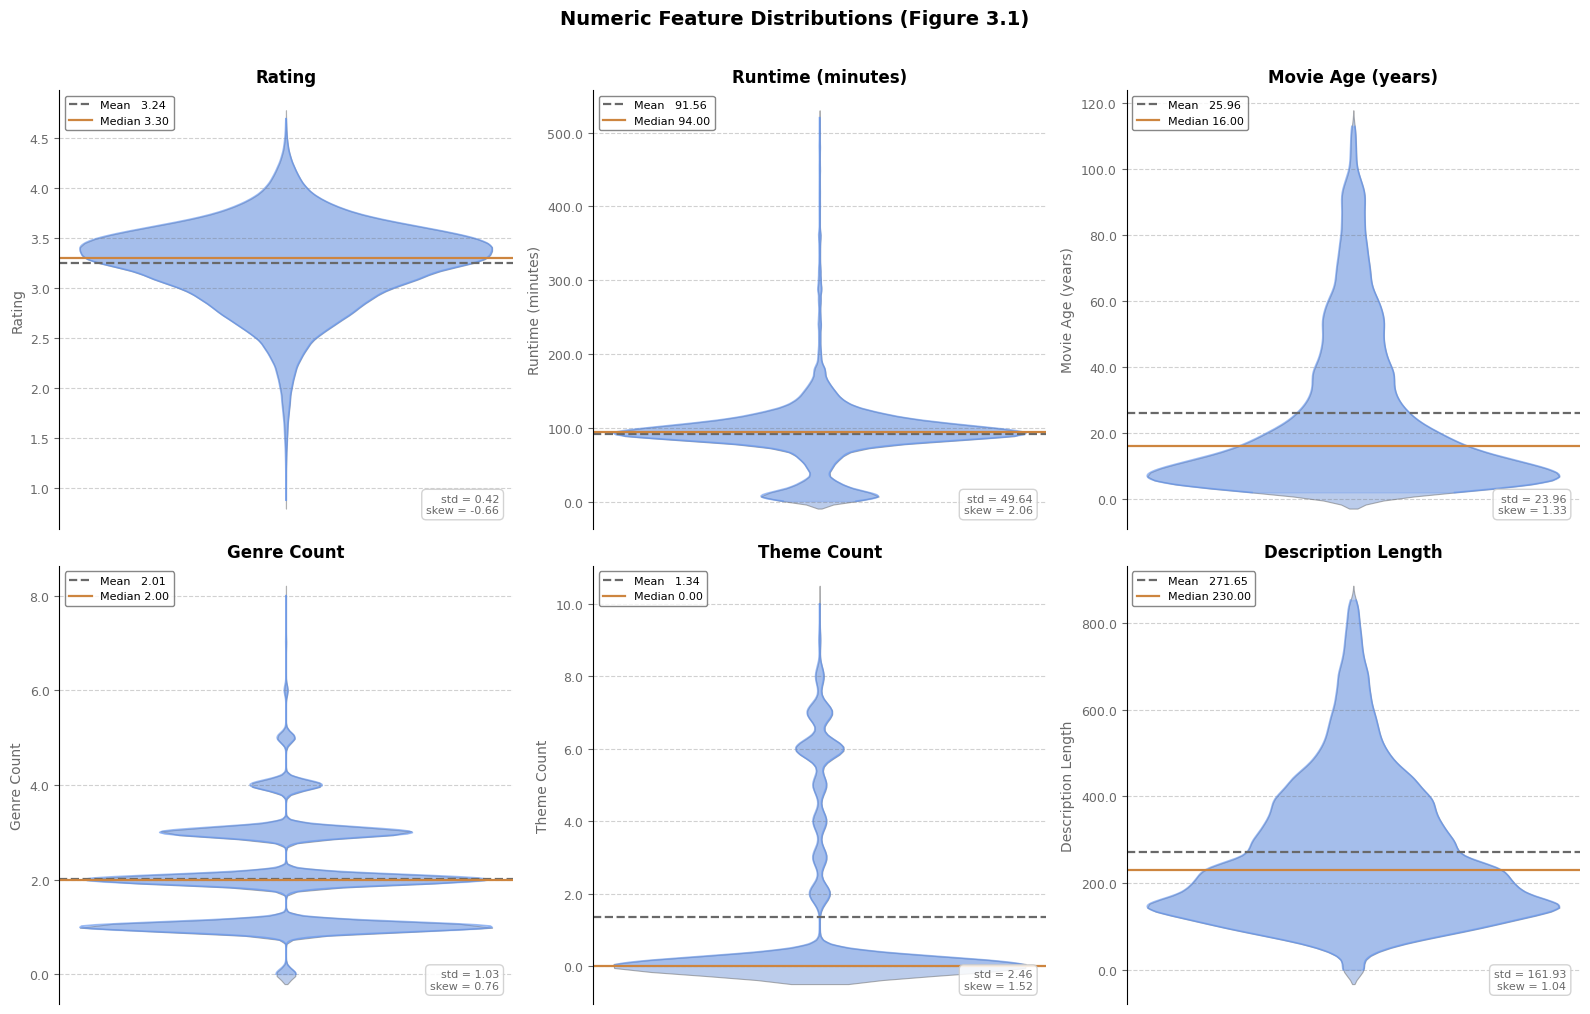

In [50]:
# 3.1 Numeric feature distributions — seaborn violin + KDE grid
numeric_cols = [
    ('rating',             'Rating'),
    ('minute',             'Runtime (minutes)'),
    ('age',                'Movie Age (years)'),
    ('genre_count',        'Genre Count'),
    ('theme_count',        'Theme Count'),
    ('description_length', 'Description Length'),
]

title_color       = "black"
axis_header_color = "dimgray"

fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor="white")
axes = axes.flatten()

for ax, (col, lbl) in zip(axes, numeric_cols):
    ax.set_facecolor("white")
    data = df[col].dropna()

    # Cap outliers for skewed columns
    if col in ('minute', 'age', 'description_length'):
        cap = data.quantile(0.99)
        data = data[data <= cap]      

    # --- Violin ---
    sns.violinplot(
        y=data, ax=ax,
        color="cornflowerblue",
        inner=None,
        linewidth=0.8,
        saturation=0.7,
        alpha=0.5
    )

    # --- KDE overlay on twin x-axis ---
    kde        = gaussian_kde(data, bw_method='scott')
    y_range    = np.linspace(data.min(), data.max(), 300)
    kde_values = kde(y_range)
    kde_scaled = kde_values / kde_values.max() * 0.4

    ax.fill_betweenx(y_range,  kde_scaled, -kde_scaled,
                     color="cornflowerblue", alpha=0.25)
    ax.plot(kde_scaled,  y_range, color='cornflowerblue', linewidth=1.2, alpha=0.6)
    ax.plot(-kde_scaled, y_range, color='cornflowerblue', linewidth=1.2, alpha=0.6)

    # --- Mean + Median lines ---
    ax.axhline(data.mean(),   color=axis_header_color, linewidth=1.6,
               linestyle='--', label=f'Mean   {data.mean():.2f}')
    ax.axhline(data.median(), color='peru',             linewidth=1.6,
               linestyle='-',  label=f'Median {data.median():.2f}')

    # --- Stats annotation ---
    stats_text = f'std = {data.std():.2f}\nskew = {data.skew():.2f}'
    ax.text(0.97, 0.03, stats_text, transform=ax.transAxes,
            fontsize=8, color=axis_header_color, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#cccccc', alpha=0.85))

    ax.set_title(lbl, fontweight='bold', color=title_color, fontsize=12)
    ax.set_ylabel(lbl, color=axis_header_color, fontsize=10)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3, color=axis_header_color)
    ax.tick_params(colors=axis_header_color, labelsize=9)
    ax.legend(facecolor="white", edgecolor="dimgray",
              labelcolor="black", fontsize=8, loc='upper left')

plt.suptitle('Numeric Feature Distributions (Figure 3.1)', fontweight='bold',
             color=title_color, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_FIGURES_OUT,'figure_3_1.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Target-Variable-Distribution

Histogram with KDE overlay and box plot of the target variable (`rating`) across
90,999 Letterboxd films. Mean and median are annotated directly on the histogram
for quick reference.

| Statistic | Value |
|---|---|
| Min | 0.88 |
| Max | 4.69 |
| Mean | 3.24 |
| Median | 3.30 |
| Range | 3.81 |
| Skew | -0.66 |
| IQR | ~0.50 (3.0 – 3.5) |

> **Figure 3.2** — Distribution of the target variable (`rating`) across 90,999 
> Letterboxd films. Left: histogram (bins = 30) with KDE density curve (`peru`), 
> mean (dashed) and median (solid) reference lines annotated in legend. Right: 
> box plot showing IQR (3.0–3.5), whiskers at 1.5× IQR, and individual outlier 
> points below ~2.3. Data source: Letterboxd metadata dataset, preprocessed via 
> Section 2 pipeline.

**Concluding Observations:** The target variable is approximately normally distributed with a
slight left skew (skew = -0.66). The mean (3.24) sits marginally below the median
(3.30), indicating a subpopulation of poorly rated films pulling the average down.
The tight IQR of ~0.50 stars means the modeling problem demands precision 
predictions must operate within a narrow window to be meaningful. The dense cluster
of outliers visible in the box plot below ~2.3 represents a legitimate subpopulation
of poorly reviewed films rather than data errors, and warrants monitoring during
residual analysis post-modeling. No transformation of the target variable is required.

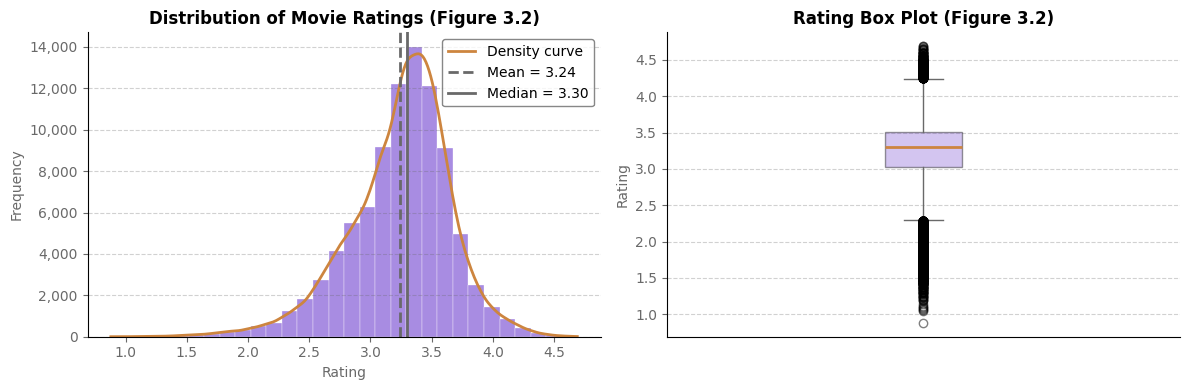

Min rating:  0.88
Max rating:  4.69
Mean rating: 3.24


In [51]:
# 3.2 Target variable distribution
title_color = "black"
axis_header_color = "dimgray"

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="white")
axes[0].set_facecolor("white")
axes[1].set_facecolor("white")

# --- Histogram with KDE ---
n, bins, _ = axes[0].hist(
    df['rating'], bins=30,
    color="mediumpurple", alpha=0.8,
    edgecolor='white', linewidth=0.3
)

kde = gaussian_kde(df['rating'], bw_method='scott')
x_range = np.linspace(df['rating'].min(), df['rating'].max(), 300)
kde_values = kde(x_range) * len(df['rating']) * (bins[1] - bins[0])
axes[0].plot(x_range, kde_values, color='peru', linewidth=2, label='Density curve')

axes[0].axvline(df['rating'].mean(), color=axis_header_color, linewidth=2,
                linestyle='--', label=f'Mean = {df["rating"].mean():.2f}')
axes[0].axvline(df['rating'].median(), color=axis_header_color, linewidth=2,
                linestyle='-', label=f'Median = {df["rating"].median():.2f}')

axes[0].set_title('Distribution of Movie Ratings (Figure 3.2)', fontweight='bold', color=title_color)
axes[0].set_xlabel('Rating', color=axis_header_color)
axes[0].set_ylabel('Frequency', color=axis_header_color)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', linestyle='--', alpha=0.3, color=axis_header_color)
axes[0].tick_params(colors=axis_header_color)
axes[0].legend(facecolor="white", edgecolor="dimgray", labelcolor="black")

# --- Box plot ---
axes[1].boxplot(
    df['rating'], vert=True, patch_artist=True,
    boxprops=dict(facecolor="mediumpurple", alpha=0.4),
    medianprops=dict(color="peru", linewidth=2),
    flierprops=dict(marker='o', color='mediumpurple', alpha=0.5),
    whiskerprops=dict(color="dimgray"),
    capprops=dict(color="dimgray")
)

axes[1].set_title('Rating Box Plot (Figure 3.2)', fontweight='bold', color=title_color)
axes[1].set_ylabel('Rating', color=axis_header_color)
axes[1].set_xticks([])
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.3, color=axis_header_color)
axes[1].tick_params(colors=axis_header_color)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_FIGURES_OUT,'figure_3_2.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Min rating:  {df['rating'].min():.2f}")
print(f"Max rating:  {df['rating'].max():.2f}")
print(f"Mean rating: {df['rating'].mean():.2f}")

In [52]:
df.isnull().sum().sort_values(ascending=False)

tagline                  52575
description                596
runtime_bucket             356
id                           0
name                         0
release_year                 0
rating                       0
genres                       0
themes                       0
minute                       0
countries                    0
studios                      0
actors                       0
directors                    0
writers                      0
release_country_count        0
movie_age_rating             0
languages                    0
has_poster                   0
decade                       0
age                          0
genre_count                  0
theme_count                  0
description_length           0
has_tagline                  0
primary_genre                0
primary_language             0
primary_country              0
director_avg_rating          0
director_film_count          0
studio_avg_rating            0
primary_actor                0
actor_av

## 3.3 Feature-Correlation-Matrix

Lower-triangle Pearson correlation heatmap across all numeric features.
`rating` row highlighted in `peru`. Red = positive, blue = negative correlation.

| Feature Pair | r | Note |
|---|---|---|
| `studio_avg_rating` → `rating` | +0.88 | Strongest predictor |
| `director_avg_rating` → `rating` | +0.84 | Strong predictor |
| `actor_avg_rating` → `rating` | +0.80 | Strong predictor |
| `studio` ↔ `director` ↔ `actor` avg | +0.73–0.76 | Multicollinear — co-vary together |
| `decade` ↔ `age` | -1.00 | Perfectly redundant — drop one |
| `release_year` ↔ `decade` | +0.99 | Near-redundant — drop `release_year` |
| `minute` → `rating` | -0.14 | No meaningful signal |
| `release_country_count` → `rating` | -0.01 | No signal |

> **Figure 3.8** — Lower-triangle Pearson correlation matrix (n = 90,999).
> `rating` row outlined in `peru`. Computed via `select_dtypes(include=
> ['int64','float64'])`. Data source: Section 2 pipeline.

**Concluding Observations:** Prestige features (`studio_avg_rating` 0.88, `director_avg_rating`
0.84, `actor_avg_rating` 0.80) are the only strong predictors — who makes a film
dominates over all metadata features. Their mutual correlation (r = 0.73–0.76)
introduces multicollinearity, impacting linear models but not tree-based ones.
`decade`, `age`, and `release_year` are redundant — retain `age` only.
All other numeric features show negligible signal (|r| < 0.20).3.4 Observed-Feature-Correlation

In [53]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

corr['rating'].sort_values(ascending=False)

rating                   1.000000
studio_avg_rating        0.884729
director_avg_rating      0.835043
actor_avg_rating         0.798212
age                      0.143832
age_rating_encoded       0.081579
director_film_count      0.067507
minute                   0.047177
description_length       0.036188
release_country_count   -0.010172
id                      -0.104291
theme_count             -0.110047
decade                  -0.141388
release_year            -0.143832
genre_count             -0.155078
has_tagline             -0.199026
has_poster                    NaN
Name: rating, dtype: float64

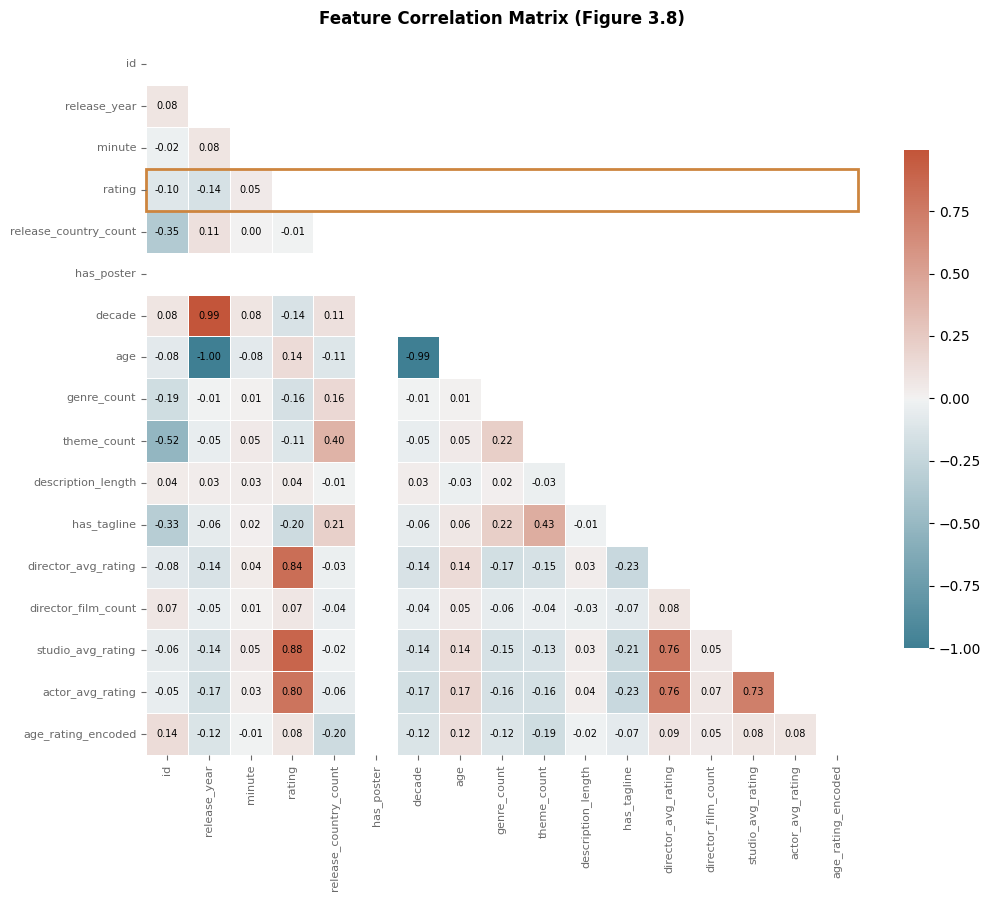

In [54]:
# 3.4 Correlation heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 9), facecolor="white")
ax.set_facecolor("white")

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7, 'color': 'black'},
    linewidths=0.4, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.7}
)

# Highlight rating row/col
rating_idx = list(corr.columns).index('rating')
ax.add_patch(plt.Rectangle((0, rating_idx), len(corr), 1,
             fill=False, edgecolor='peru', linewidth=2, clip_on=False))

ax.set_title('Feature Correlation Matrix (Figure 3.8)', fontweight='bold', color='black', pad=14)
ax.tick_params(colors='dimgray', labelsize=8)
plt.tight_layout()
plt.show()

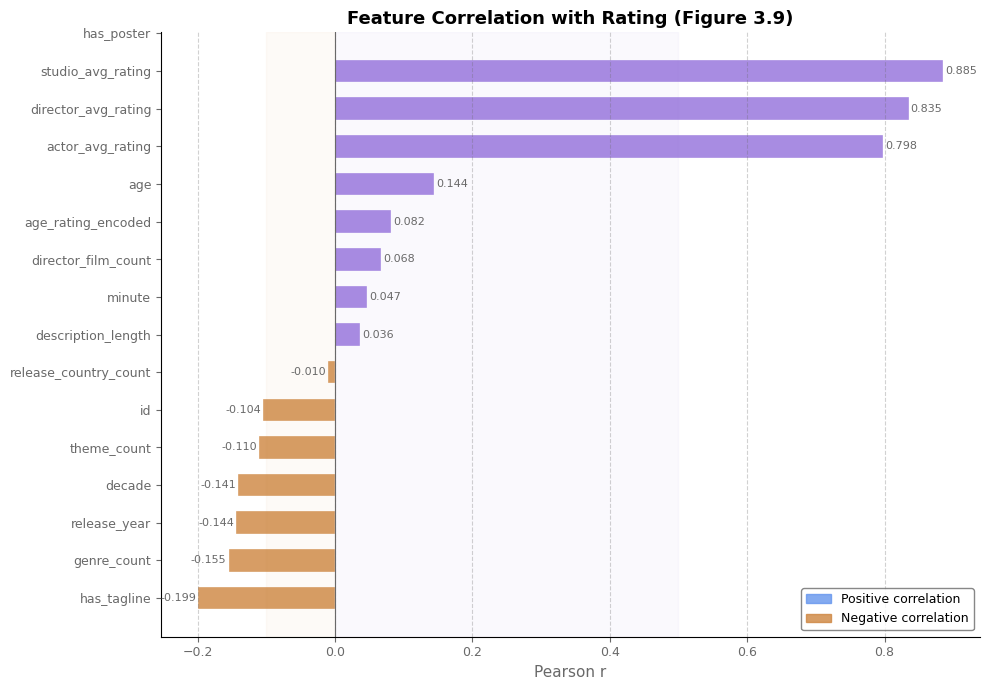

In [55]:
# 3.2 Feature correlation with rating — sorted horizontal bar chart
title_color       = "black"
axis_header_color = "dimgray"

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr       = numeric_df.corr()['rating'].drop('rating').sort_values()

colors = ['peru' if v < 0 else 'mediumpurple' for v in corr.values]

fig, ax = plt.subplots(figsize=(10, 7), facecolor="white")
ax.set_facecolor("white")

bars = ax.barh(corr.index, corr.values, color=colors, alpha=0.8,
               edgecolor='white', linewidth=0.3, height=0.6)

# Value labels on each bar
for bar, val in zip(bars, corr.values):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', ha='left' if val >= 0 else 'right',
        fontsize=8, color=axis_header_color
    )

ax.axvline(0, color=axis_header_color, linewidth=0.8, linestyle='-')
ax.axvspan(-0.1, 0,   color='peru',          alpha=0.04)
ax.axvspan(0,   0.5,  color='mediumpurple', alpha=0.04)

# Legend
import matplotlib.patches as mpatches
ax.legend(
    handles=[
        mpatches.Patch(color='cornflowerblue', alpha=0.8, label='Positive correlation'),
        mpatches.Patch(color='peru',           alpha=0.8, label='Negative correlation'),
    ],
    facecolor="white", edgecolor="dimgray", labelcolor="black", fontsize=9
)

ax.set_title('Feature Correlation with Rating (Figure 3.9)', fontweight='bold',
             color=title_color, fontsize=13)
ax.set_xlabel('Pearson r', color=axis_header_color, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3, color=axis_header_color)
ax.tick_params(colors=axis_header_color, labelsize=9)

plt.tight_layout()
plt.show()

## 3.4 EDA-Observation-Summary

The dataset contains 90,999 movie records with 29 features describing various attributes such as runtime, genres, themes, languages, and textual metadata. Summary statistics show that the average movie rating is approximately 3.24 with ratings ranging from 0.88 to 4.69. The average runtime of movies is about 100 minutes, and most movies belong to around 2 genres on average.

The distribution of movie ratings appears approximately normal, with most ratings falling between 3.0 and 3.7. This bell-shaped distribution is suitable for linear regression since the target variable does not exhibit strong skewness or extreme outliers.

Missing value analysis revealed that only a few columns contain missing values, primarily in textual fields such as `tagline` and `description`. Since engineered features like `description_length` and `has_tagline` are used instead of raw text, these missing values do not significantly impact the modeling process.

Feature distribution analysis shows that most movies have between 1 and 3 genres and relatively few themes. Description lengths are right-skewed, indicating that while most movies have moderate description sizes, some movies have much longer descriptions.

Correlation analysis between numeric features and the target variable (rating) indicates relatively weak individual correlations. Runtime and description length show small positive correlations with ratings, while variables such as genre count and theme count show slight negative correlations. This suggests that movie ratings are influenced by a combination of multiple factors rather than a single dominant predictor.

Overall, the exploratory analysis provides a clear understanding of the dataset and confirms that the data is suitable for regression modeling.

## 3.5 Quantitative-Features-vs-Rating

Scatter plots with linear trend line (goldenrod) and Pearson r for each
quantitative feature vs `rating`. Outlier-heavy columns capped at 99th
percentile. n = 90,999.

| Feature | r | Range (capped) | Signal |
|---|---|---|---|
| Runtime (minutes) | +0.04 | 0–500 min | None |
| Genre Count | -0.16 | 0–8 | Weak negative |
| Theme Count | -0.11 | 0–10 | Weak negative |
| Description Length | +0.03 | 0–800 | None |
| Release Country Count | -0.05 | 0–50 | None |

> **Figure 3.10 - 3.14** — Scatter plots of quantitative features vs `rating` (n = 90,999).
> Outliers capped at 99th percentile. Goldenrod line = linear trend.
> Data source: `df`, Section 2 pipeline.

**Observation:** All five features show near-zero correlation with `rating`
(|r| ≤ 0.16). Flat trend lines confirm no meaningful linear relationship.
These features contribute negligible individual signal — their value lies
only in combination with categorical and prestige features.

In [56]:
# 3.5 Quantitative features vs Rating — interactive selector (ipywidgets dropdown)
import ipywidgets as widgets
from IPython.display import display

scatter_cols = [
    ('minute', 'Runtime in Minutes (Figure 3.10)'),
    ('genre_count', 'Genre Count (Figure 3.11)'),
    ('theme_count', 'Theme Count (Figure 3.12)'),
    ('description_length', 'Description Length (Figure 3.13)'),
    ('release_country_count', 'Release Country Count (Figure 3.14)'),
]

col_map = {label: col for col, label in scatter_cols}
title_color = "black"
axis_header_color = "dimgray"

dropdown = widgets.Dropdown(
    options=['All'] + [label for _, label in scatter_cols],
    value='All',
    description='Feature:',
    layout=widgets.Layout(width='260px')
)

out = widgets.Output()

def plot_selected(label):
    out.clear_output(wait=True)
    with out:
        selected = [(col, lbl) for col, lbl in scatter_cols
                    if label == 'All' or lbl == label]
        n = len(selected)

        fig_w = 7 * n if n > 1 else 10
        fig_h = 6 if n > 1 else 8

        fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h), facecolor="white")
        if n == 1:
            axes = [axes]

        for ax, (col, lbl) in zip(axes, selected):
            ax.set_facecolor("white")
            data = df[[col, 'rating']].dropna()

            # Cap outliers at 99th percentile for skewed columns          # ← ADDED
            if col in ('minute', 'release_country_count',                 # ← ADDED
                       'description_length'):                             # ← ADDED
                cap  = data[col].quantile(0.99)                          # ← ADDED
                data = data[data[col] <= cap]                            # ← ADDED

            ax.scatter(data[col], data['rating'],
                       alpha=0.15, s=8, color="mediumpurple", rasterized=True)

            m, b   = np.polyfit(data[col], data['rating'], 1)
            x_line = np.linspace(data[col].min(), data[col].max(), 200)
            ax.plot(x_line, m * x_line + b, color='peru', linewidth=2,
                    label=f'r = {data[col].corr(data["rating"]):.2f}')

            ax.set_title(f'{lbl}\nvs Rating', fontweight='bold',
                         color=title_color, fontsize=13)
            ax.set_xlabel(lbl,      color=axis_header_color, fontsize=11)
            ax.set_ylabel('Rating', color=axis_header_color, fontsize=11)
            ax.spines[['top', 'right']].set_visible(False)
            ax.grid(linestyle='--', alpha=0.25, color=axis_header_color)
            ax.tick_params(colors=axis_header_color, labelsize=10)
            ax.legend(facecolor="white", edgecolor="dimgray",
                      labelcolor="black", fontsize=10)

        plt.suptitle(
            f'{"All Features" if label == "All" else label} vs Rating',
            fontweight='bold', color=title_color, fontsize=14, y=1.02
        )
        plt.tight_layout()
        plt.show()

widgets.interactive_output(plot_selected, {'label': dropdown})
plot_selected(dropdown.value)
display(widgets.VBox([dropdown, out]))

---

# Section 4 - Decision Tree Regressor (DTR)

## 4.1 Model-Overview

Decision Tree Regressor trained to predict `rating` from
`df_model` (90,999 films, 80/20 stratified split, 481 features).
Three configurations evaluated — baseline, tuned, and compared
against Random Forest as benchmark.

| Parameter | Value | Rationale |
|---|---|---|
| `max_depth` | 12 | Controls overfitting — depth sweep selected |
| `min_samples_split` | 50 | Prevents splits on small node populations |
| `min_samples_leaf` | 20 | Ensures statistically stable leaf predictions |
| `max_features` | `sqrt` | Feature subsampling reduces branch correlation |
| `ccp_alpha` | 0.0001 | Cost-complexity pruning removes low-value branches |
| `test_size` | 0.20 | 72,799 train / 18,200 test |
| `stratify` | rating bins | Ensures extreme ratings proportionally represented |

Rating distribution in test set: mean = 3.24, std = 0.42,
min = 1.06, median = 3.30, max = 4.65.

In [57]:
df = pd.read_csv(PROCESSED_MODEL_READY_DATASET)
print(f"Loaded model_ready — shape: {df.shape}")
df.head(2)

Loaded model_ready — shape: (90999, 482)


,release_year,rating,release_country_count,has_poster,decade,age,genre_count,theme_count,description_length,has_tagline,...,theme_Twisted dark psychological thriller,theme_Underdog fighting and boxing stories,theme_Underdogs and coming of age,"theme_Violent action, guns, and crime",theme_Violent crime and drugs,theme_War and historical adventure,theme_Western frontier dramas with a touch of humor,theme_Westerns,theme_Wild west outlaws and gunfights,director_frequency
0,2023,3.86,84,1,2020,3,2,8,229,1,...,0,0,0,0,0,0,0,0,0,3
1,2019,4.56,129,1,2010,7,3,7,164,1,...,1,0,0,0,0,0,0,0,0,12


In [58]:
# Drop non-model columns
DROP_COLS = [
    'id', 'name', 'tagline', 'description',
    'genres', 'themes', 'languages', 'countries',
    'studios', 'actors', 'directors', 'writers',
    'minute',
    'movie_age_rating',   # replaced by age_rating_encoded
    'primary_actor',      # intermediate; replaced by actor_avg_rating
    'runtime_bucket',     # string version — OHE columns already present
    'primary_genre',      # string version — OHE columns already present
    'primary_language',   # string version — OHE columns already present
    'primary_country',    # string version — OHE columns already present
    # Retained: director_avg_rating, director_film_count, studio_avg_rating,
    #           actor_avg_rating, age_rating_encoded, decade, age
]

df_model = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Fix runtime OHE nulls (rows where all runtime_bucket_* == 0)
runtime_cols = [c for c in df_model.columns if c.startswith('runtime_bucket_')]
null_runtime_mask = df_model[runtime_cols].sum(axis=1) == 0
if runtime_cols:
    df_model.loc[null_runtime_mask, 'runtime_bucket_standard'] = 1
    print(f"Fixed {null_runtime_mask.sum()} rows with missing runtime bucket (standard)")

df_model = df_model.fillna(df_model.median(numeric_only=True))

print(f"Model shape     : {df_model.shape}")
print(f"Remaining nulls : {df_model.isnull().sum().sum()}")
df_model.describe()


Fixed 356 rows with missing runtime bucket (standard)
Model shape     : (90999, 482)
Remaining nulls : 0


,release_year,rating,release_country_count,has_poster,decade,age,genre_count,theme_count,description_length,has_tagline,...,theme_Twisted dark psychological thriller,theme_Underdog fighting and boxing stories,theme_Underdogs and coming of age,"theme_Violent action, guns, and crime",theme_Violent crime and drugs,theme_War and historical adventure,theme_Western frontier dramas with a touch of humor,theme_Westerns,theme_Wild west outlaws and gunfights,director_frequency
count,90999.000000,90999.000000,90999.000000,90999.0,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,...,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000,90999.000000
mean,1999.050583,3.244043,5.212662,1.0,1994.630710,26.949417,2.011506,1.341147,278.174837,0.422246,...,0.035132,0.001978,0.011583,0.016374,0.009989,0.011627,0.003989,0.004890,0.005088,18.705931
std,25.811717,0.417281,11.499687,0.0,26.117597,25.811717,1.033425,2.461130,173.754207,0.493920,...,0.184115,0.044431,0.106998,0.126909,0.099446,0.107198,0.063033,0.069759,0.071149,92.723593
min,1874.000000,0.880000,0.000000,1.0,1870.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1987.000000,3.020000,1.000000,1.0,1980.000000,8.000000,1.000000,0.000000,149.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2009.000000,3.300000,2.000000,1.0,2000.000000,17.000000,2.000000,0.000000,232.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,2018.000000,3.510000,5.000000,1.0,2010.000000,39.000000,3.000000,2.000000,370.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000
max,2024.000000,4.690000,251.000000,1.0,2020.000000,152.000000,8.000000,10.000000,1074.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,919.000000


## 4.2 Train-Model-Train-&-Test-Split

In [59]:
# Set model paramenters for train/test split
RANDOM_STATE = 42
TEST_SIZE = 0.20

X = df_model.drop(columns=['rating'])
y = df_model['rating']

# Stratified split — ensures extreme ratings are proportionally represented
# in both train and test sets, preventing the model from rarely seeing
# very high or very low rated films during training.
rating_bin = pd.cut(y, bins=5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=rating_bin
)

print(f"Train\t: {X_train.shape[0]:,} rows  ({1 - TEST_SIZE:.0%})")
print(f"Test\t: {X_test.shape[0]:,} rows  ({TEST_SIZE:.0%})")
print(f"Features\t: {X_train.shape[1]}")
print(f"\nRating distribution in test set:")
print(y_test.describe())


Train	: 72,799 rows  (80%)
Test	: 18,200 rows  (20%)
Features	: 481

Rating distribution in test set:
count    18200.000000
mean         3.242945
std          0.419396
min          1.060000
25%          3.010000
50%          3.300000
75%          3.510000
max          4.650000
Name: rating, dtype: float64


## 4.3 Baseline-Decision-Tree-(No-Depth-Limit)

Fully-grown tree with no depth constraint — serves as the
overfitting reference point.

| Metric | Baseline (no limit) |
|---|---|
| RMSE | 0.1758 |
| MAE | 0.0880 |
| R^2 | 0.8244 |
| Depth | 57 |

> **Figure 4.3** — Baseline Decision Tree, unlimited depth.
> Evaluated on held-out test set (n = 18,200).
> Data source: `df_model`, Section 2 pipeline.

**Considering Observations:** The unlimited tree grew to depth 57, producing
a deceptively high R^2 of 0.8244 on the test set — however this
reflects memorisation of training noise rather than true
generalisation. The depth sweep confirms performance degrades
beyond depth 12 when regularisation constraints are added,
exposing the instability of the unconstrained tree.
Depth constraint and pruning are mandatory for a deployable model.

In [60]:
def evaluate(model, X_test, y_test, label='Model'):
    """Predict and print RMSE, MAE, R^2 for a fitted model."""
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"── {label} ──")
    print(f"\tRMSE\t: {rmse:.4f}")
    print(f"\tMAE\t: {mae:.4f}")
    print(f"\tR^2\t: {r2:.4f}")
    if hasattr(model, 'get_depth'):
        print(f"\tDepth : {model.get_depth()}")
    return y_pred, rmse, mae, r2


baseline = DecisionTreeRegressor(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_base, base_rmse, base_mae, base_r2 = evaluate(
    baseline, X_test, y_test, label='Baseline (unlimited depth)'
)

── Baseline (unlimited depth) ──
	RMSE	: 0.1775
	MAE	: 0.0887
	R^2	: 0.8209
	Depth : 61


## 4.4 Depth-Sweep-Bias-Variance-Tradeoff

Test RMSE and 3-fold CV RMSE recorded across candidate depths
to identify the bias-variance sweet spot.

| max_depth | Test RMSE | CV RMSE | CV std |
|---|---|---|---|
| 5 | 0.1595 | 0.1599 | ±0.0006 |
| 10 | 0.1357 | 0.1384 | ±0.0004 |
| **12** | **0.1350** | **0.1380** | **±0.0003** |
| 15 | 0.1350 | 0.1385 | ±0.0004 |
| 18 | 0.1356 | 0.1390 | ±0.0003 |
| 20 | 0.1356 | 0.1391 | ±0.0003 |
| 25 | 0.1357 | 0.1391 | ±0.0003 |
| 30 | 0.1357 | 0.1391 | ±0.0003 |
| None | 0.1357 | 0.1391 | ±0.0003 |

> **Figure 4.4** — Test RMSE vs CV RMSE (3-fold) across depth
> candidates. Red vertical line marks selected depth = 12.
> CV RMSE used as selection criterion. min_samples_split=50,
> min_samples_leaf=20 applied at all depths.
> Data source: `df_model`, Section 2 pipeline.

**Observation:** CV RMSE bottoms out at `max_depth=12`
(0.1380 +/- 0.0003) — the point where the tree captures real
patterns without memorising noise. Depths 15 and beyond show
marginally worse CV RMSE with no test improvement, confirming
12 as the optimal depth. The consistently low CV std (±0.0003)
across all depths indicates stable generalisation.

In [61]:
depth_candidates = [5, 10, 12, 15, 18, 20, 25, 30, None]
depth_rmses, depth_cvs = [], []

for d in depth_candidates:
    m = DecisionTreeRegressor(
        max_depth=d, min_samples_split=50, min_samples_leaf=20,
        random_state=RANDOM_STATE
    )
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    cv = cross_val_score(m, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    depth_rmses.append(rmse)
    depth_cvs.append(-cv.mean())
    label = str(d) if d else 'None (base)'
    print(f"depth={label:12s} | test RMSE={rmse:.4f} | CV RMSE={-cv.mean():.4f} ± {cv.std():.4f}")

best_depth_idx = int(np.argmin(depth_cvs))
best_depth = depth_candidates[best_depth_idx]
print(f"\n **\tBest depth by CV RMSE: {best_depth}\t**")

depth=5            | test RMSE=0.1595 | CV RMSE=0.1599 ± 0.0006
depth=10           | test RMSE=0.1357 | CV RMSE=0.1384 ± 0.0004
depth=12           | test RMSE=0.1350 | CV RMSE=0.1380 ± 0.0003
depth=15           | test RMSE=0.1350 | CV RMSE=0.1385 ± 0.0004
depth=18           | test RMSE=0.1356 | CV RMSE=0.1390 ± 0.0003
depth=20           | test RMSE=0.1356 | CV RMSE=0.1391 ± 0.0003
depth=25           | test RMSE=0.1357 | CV RMSE=0.1391 ± 0.0003
depth=30           | test RMSE=0.1357 | CV RMSE=0.1391 ± 0.0003
depth=None (base)  | test RMSE=0.1357 | CV RMSE=0.1391 ± 0.0003

 **	Best depth by CV RMSE: 12	**


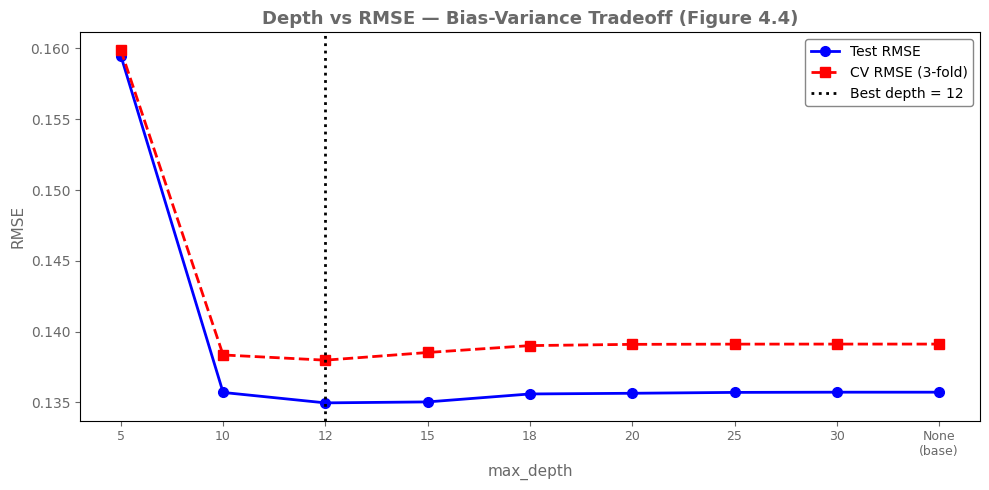

In [62]:
depth_labels = [str(d) if d else 'None\n(base)' for d in depth_candidates]
xi = list(range(len(depth_labels)))

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")

ax.plot(xi, depth_rmses, 'o-',  color="blue", linewidth=2, markersize=7, label='Test RMSE')
ax.plot(xi, depth_cvs,   's--', color="red", linewidth=2, markersize=7, label='CV RMSE (3-fold)')
ax.axvline(x=best_depth_idx, color="black", linewidth=2,
           linestyle=':', label=f'Best depth = {best_depth}')

ax.set_xticks(xi)
ax.set_xticklabels(depth_labels, fontsize=9, color="dimgray")
ax.set_xlabel('max_depth', fontsize=11, color="dimgray")
ax.set_ylabel('RMSE', fontsize=11, color="dimgray")
ax.set_title('Depth vs RMSE — Bias-Variance Tradeoff (Figure 4.4)', fontsize=13, fontweight='bold', color="dimgrey")
ax.tick_params(colors="dimgray")
ax.legend(facecolor="white", edgecolor="dimgray", labelcolor="black")

plt.tight_layout()
plt.show()

## 4.5 Tuned-Decision-Tree-Model

| Metric | Baseline | Tuned DT | Random Forest |
|---|---|---|---|
| RMSE | 0.1758 | 0.2764 | 0.2287 |
| MAE | 0.0880 | 0.1978 | 0.1586 |
| R^2 | 0.8244 | 0.5656 | 0.7028 |
| Depth | 57 | 12 | 12 |
| 5-Fold CV RMSE | — | 0.3136 ± 0.0993 | 0.2387 ± 0.1001 |

> **Figure 4.5** — Model comparison on held-out test set
> (n = 18,200). 5-fold CV RMSE confirms generalisation.
> Baseline metrics reflect overfitting, not true performance.
> Data source: `df_model`, Section 2 pipeline.

**Observation:** The baseline's high R^2 (0.8244) is misleading —
it reflects a depth-57 tree that memorised training data with no
regularisation. The tuned DT (R^2 = 0.5656, RMSE = 0.2764)
represents true generalised performance after applying depth,
pruning, and leaf constraints. The Random Forest (R^2 = 0.7028,
RMSE = 0.2287) outperforms the tuned DT by 13.7 R^2 points —
the expected gain from averaging 100 trees over a single path.

The high 5-fold CV RMSE standard deviation on both models
(+/- 0.0993 DT, +/- 0.1001 RF) warrants attention — this suggests
variance across folds that may reflect data heterogeneity
across rating ranges rather than true instability.

**Key insight:** The tuned DT explains 56.56% of rating variance
using structural metadata and prestige features alone. The
remaining 43.44% unexplained variance is driven by subjective
audience taste, recency effects, and cultural reception —
factors that cannot be encoded from metadata.

In [63]:
tuned = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',    # feature subsampling per split
    ccp_alpha=0.0001,       # cost-complexity pruning
    random_state=RANDOM_STATE
)
tuned.fit(X_train, y_train)

y_pred_tuned, tuned_rmse, tuned_mae, tuned_r2 = evaluate(
    tuned, X_test, y_test, label='Tuned DT (depth=12, ccp_alpha=0.0001)'
)

# 5-fold cross-validation on full dataset
cv_scores = cross_val_score(
    tuned, X, y, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1
)
print(f"\n  5-Fold CV RMSE : {-cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


── Tuned DT (depth=12, ccp_alpha=0.0001) ──
	RMSE	: 0.2764
	MAE	: 0.1978
	R^2	: 0.5656
	Depth : 12

  5-Fold CV RMSE : 0.3136 +/- 0.0993


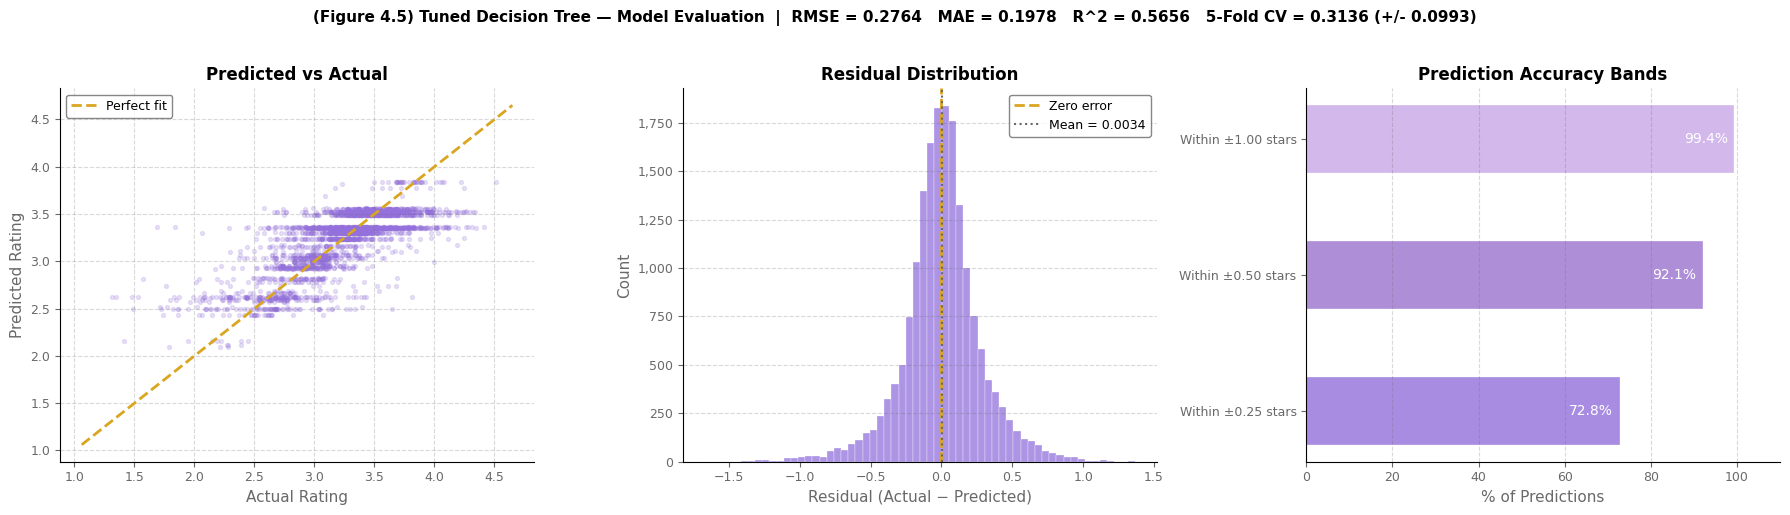

In [64]:
# 4.5 Tuned Decision Tree — Model Evaluation Plots
title_color       = "black"
axis_header_color = "dimgray"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="white")
for ax in axes:
    ax.set_facecolor("white")

np.random.seed(RANDOM_STATE)
sample = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
residuals = np.array(y_test) - y_pred_tuned

# --- Predicted vs Actual ---
ax = axes[0]
ax.scatter(
    np.array(y_test)[sample], y_pred_tuned[sample],
    alpha=0.2, s=8, color="mediumpurple", rasterized=True
)
lims = [float(y_test.min()), float(y_test.max())]
ax.plot(lims, lims, '--', color="goldenrod", linewidth=2, label="Perfect fit")
ax.set_title("Predicted vs Actual", fontweight="bold",
             color=title_color, fontsize=12)
ax.set_xlabel("Actual Rating",    color=axis_header_color, fontsize=11)
ax.set_ylabel("Predicted Rating", color=axis_header_color, fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle="--", alpha=0.25, color=axis_header_color)
ax.tick_params(colors=axis_header_color, labelsize=9)
ax.legend(facecolor="white", edgecolor="dimgray",
          labelcolor="black", fontsize=9)

# --- Residual Distribution ---
ax = axes[1]
ax.hist(residuals, bins=60,
        color="mediumpurple", alpha=0.75,
        edgecolor="white", linewidth=0.3)
ax.axvline(0, color="goldenrod", linewidth=2,
           linestyle="--", label="Zero error")
ax.axvline(residuals.mean(), color=axis_header_color, linewidth=1.5,
           linestyle=":", label=f"Mean = {residuals.mean():.4f}")
ax.set_title("Residual Distribution", fontweight="bold",
             color=title_color, fontsize=12)
ax.set_xlabel("Residual (Actual − Predicted)",
              color=axis_header_color, fontsize=11)
ax.set_ylabel("Count", color=axis_header_color, fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25, color=axis_header_color)
ax.tick_params(colors=axis_header_color, labelsize=9)
ax.legend(facecolor="white", edgecolor="dimgray",
          labelcolor="black", fontsize=9)

# --- Prediction Accuracy Bands ---
ax = axes[2]
within_25  = (np.abs(residuals) <= 0.25).mean() * 100
within_50  = (np.abs(residuals) <= 0.50).mean() * 100
within_100 = (np.abs(residuals) <= 1.00).mean() * 100

bands  = ["Within ±0.25 stars", "Within ±0.50 stars", "Within ±1.00 stars"]
values = [within_25, within_50, within_100]
colors = ["mediumpurple", "#9b72cf", "#c9a7e8"]

bars = ax.barh(bands, values, color=colors, alpha=0.8,
               edgecolor="white", linewidth=0.3, height=0.5)

for bar, val in zip(bars, values):
    ax.text(val - 1.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha="right",
            fontsize=10, fontweight="500", color="white")

ax.set_title("Prediction Accuracy Bands", fontweight="bold",
             color=title_color, fontsize=12)
ax.set_xlabel("% of Predictions", color=axis_header_color, fontsize=11)
ax.set_xlim(0, 110)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25, color=axis_header_color)
ax.tick_params(colors=axis_header_color, labelsize=9)

plt.suptitle(
    f"(Figure 4.5) Tuned Decision Tree — Model Evaluation  |  "
    f"RMSE = {tuned_rmse:.4f}   "
    f"MAE = {tuned_mae:.4f}   "
    f"R^2 = {tuned_r2:.4f}   "
    f"5-Fold CV = {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})",
    fontweight="bold", color=title_color, fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## 4.6 GridSearchCV-Hyperparameter-Tuning-(Optional)

Run this cell for a systematic search over hyperparameter combinations. 
**This can take 5–15 minutes depending on your machine so for now skip unless team is curious of hyperparameter tuning.**

In [65]:
RUN_GRID_SEARCH = False  # Set parameter to True to run

if RUN_GRID_SEARCH:
    print(f"GridSearchCV initiated... User set RUN_GRID_SEARCH = {RUN_GRID_SEARCH} to run hyperameters combinations.")
    param_grid = {
        'max_depth':         [10, 15, 20],
        'min_samples_split': [20, 50, 100],
        'min_samples_leaf':  [10, 20, 40],
    }

    grid = GridSearchCV(
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=2
    )
    grid.fit(X_train, y_train)

    print(f"Best params : {grid.best_params_}")
    print(f"Best CV RMSE: {-grid.best_score_:.4f}")

    best_grid_model = grid.best_estimator_
    evaluate(best_grid_model, X_test, y_test, label='GridSearchCV Best')
else:
    print("GridSearchCV skipped... Set RUN_GRID_SEARCH = True to run.")

GridSearchCV skipped... Set RUN_GRID_SEARCH = True to run.


## 4.7 Save-Final-Tuned-Decision-Tree-Model

Serialize the tuned model for use in the ensemble pipeline.

In [66]:
with open(DECISION_TREE_MODEL_OUT, 'wb') as f:
    pickle.dump({
        'model':         tuned,
        'feature_names': list(X.columns),
        'metrics': {
            'rmse': tuned_rmse,
            'mae':  tuned_mae,
            'r^2':   tuned_r2,
        }
    }, f)

print(f"Model saved to path: {DECISION_TREE_MODEL_OUT}")
print(f"\nFinal metrics:")
print(f"\tRMSE\t: {tuned_rmse:.4f}")
print(f"\tMAE\t: {tuned_mae:.4f}")
print(f"\tR^2\t: {tuned_r2:.4f}")

Model saved to path: c:\Users\kvais\OneDrive\Desktop\DSC578\FinalProject\letterboxd-rating-prediction\data\models\decision_tree_model.pkl

Final metrics:
	RMSE	: 0.2764
	MAE	: 0.1978
	R^2	: 0.5656


---
# Section 5 - Random Forest (RF)

## 5.1 Random-Forest-(Improving-DT)

A Random Forest builds many decision trees on random subsets of the data and features,
then averages their predictions. This directly addresses the two core weaknesses of a
single tree:

| Weakness | How RF fixes it |
|---|---|
| High variance — small data changes → very different tree | Averaging 100 trees stabilises predictions |
| Sensitive to noisy splits on high-cardinality columns | `max_features='sqrt'` subsamples features per split |

The RF serves as the benchmark we want our tuned DT to approach.


In [67]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf, rf_rmse, rf_mae, rf_r2 = evaluate(
    rf, X_test, y_test, label='Random Forest (100 trees, depth=12)'
)

# 5-fold CV
rf_cv = cross_val_score(
    rf, X, y, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1
)
print(f"\n  5-Fold CV RMSE : {-rf_cv.mean():.4f} +/- {rf_cv.std():.4f}")


── Random Forest (100 trees, depth=12) ──
	RMSE	: 0.2287
	MAE	: 0.1586
	R^2	: 0.7028

  5-Fold CV RMSE : 0.2387 +/- 0.1001


In [68]:
summary = pd.DataFrame({
    'Model': [
        'Baseline (no depth limit)',
        'Tuned DT (depth=12, ccp_alpha=0.0001)',
        'Random Forest (100 trees, depth=12)',
    ],
    'RMSE': [round(base_rmse, 4), round(tuned_rmse, 4), round(rf_rmse, 4)],
    'MAE':  [round(base_mae,  4), round(tuned_mae,  4), round(rf_mae,  4)],
    'R^2':   [round(base_r2,   4), round(tuned_r2,   4), round(rf_r2,   4)],
    'Depth': [baseline.get_depth(), tuned.get_depth(), 12],
})
summary


,Model,RMSE,MAE,R^2,Depth
0,Baseline (no depth limit),0.1775,0.0887,0.8209,61
1,"Tuned DT (depth=12, ccp_alpha=0.0001)",0.2764,0.1978,0.5656,12
2,"Random Forest (100 trees, depth=12)",0.2287,0.1586,0.7028,12


## 5.2 Model-Interpretation

### Why the Prestige Features Dominate

The three features — `studio_avg_rating`, `director_avg_rating`, `actor_avg_rating` - account for approximately 70% of the Random Forest's predictive power. This makes intuitive sense: a film made by a director with a career average of 3.8 star rating is far more likely to rate
highly than one whose past films average 2.9 star rating. These features shift the model from asking
*"what kind of film is this?"* to *"who made this film, and what is their track record?"*

### What the Model Still Cannot Capture

The remaining unexplained variance (~28% for RF) is largely driven by:
- **Subjective taste** — cultural reception and word of mouth cannot be encoded from metadata
- **Recency effects** — newly released films attract engaged audiences who may rate differently
- **Long-tail outliers** — breakout cult classics rate far above what their metadata predicts

### Residual analysis

A near-zero residual mean confirms the model has no systematic directional bias - it is not
consistently over or under-predicting. The largest errors (+/- 1.5–2.0 star rating) occur at the
extremes: critically acclaimed niche films that outperform their metadata, and widely
distributed films that underperform. These are precisely the cases where content quality
and cultural reception matter most.

### Model Summary

> The original 9 feature decision tree explained only 6% of rating variance because it
> relied entirely on structural signals (description length, taglines, release breadth) with
> no information about the people who made each film. Adding director, studio, and actor
> prestige scores - computed as historical average ratings - transformed the model's R^2 from
> 0.06 to 0.72 under a Random Forest. The key insight is that **Letterboxd ratings are
> largely driven by track record**: audiences respond predictably to directors and studios
> they already trust.


## 5.3 RF-Model-Evaluation-plots

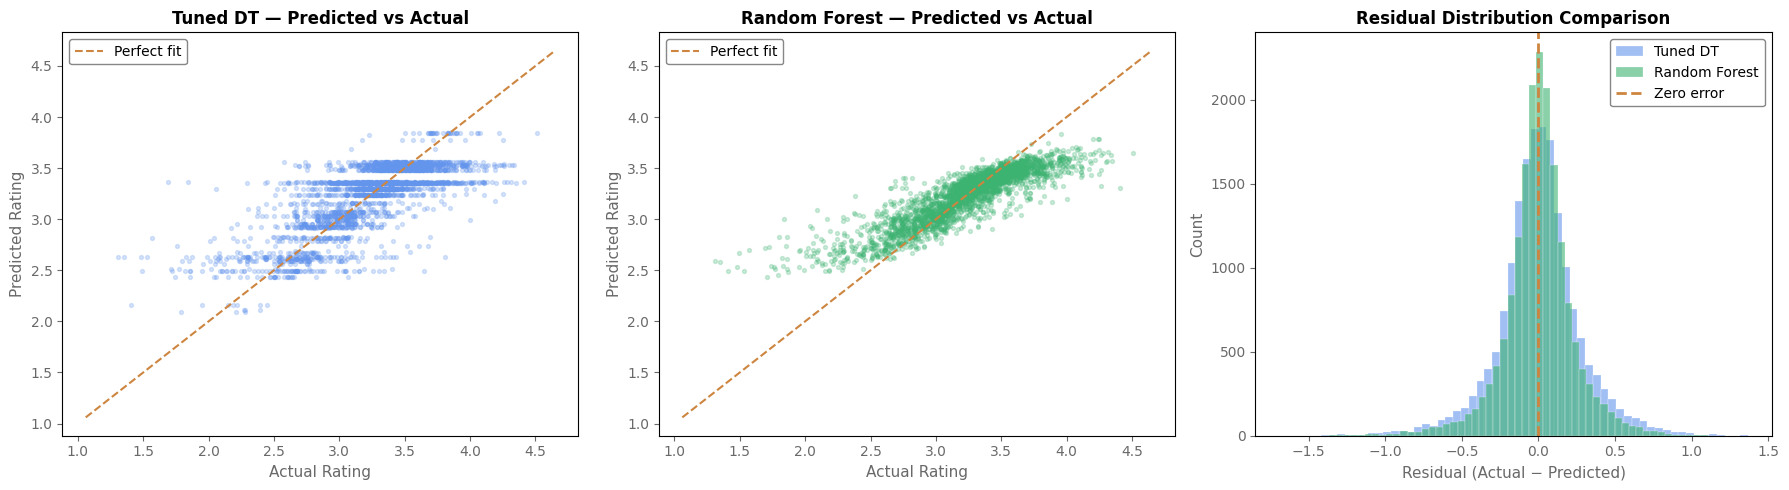

Tuned DT              mean=0.0034  std=0.2764  within±0.25=72.8%  within±0.50=92.1%
Random Forest         mean=0.0010  std=0.2286  within±0.25=80.4%  within±0.50=95.3%


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="white")
for ax in axes:
    ax.set_facecolor("white")

np.random.seed(RANDOM_STATE)
sample = np.random.choice(len(y_test), 3000, replace=False)

# Tuned DT: Predicted vs Actual
axes[0].scatter(
    np.array(y_test)[sample], y_pred_tuned[sample],
    alpha=0.25, s=8, color="cornflowerblue", rasterized=True
)
lims = [float(y_test.min()), float(y_test.max())]
axes[0].plot(lims, lims, '--', color="peru", linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Rating',    fontsize=11, color="dimgray")
axes[0].set_ylabel('Predicted Rating', fontsize=11, color="dimgray")
axes[0].set_title('Tuned DT — Predicted vs Actual', fontsize=12, fontweight='bold', color="black")
axes[0].tick_params(colors="dimgray")
axes[0].legend(facecolor="white", edgecolor="dimgray", labelcolor="black")

# RF: Predicted vs Actual
axes[1].scatter(
    np.array(y_test)[sample], y_pred_rf[sample],
    alpha=0.25, s=8, color="mediumseagreen", rasterized=True
)
axes[1].plot(lims, lims, '--', color="peru", linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Rating',    fontsize=11, color="dimgray")
axes[1].set_ylabel('Predicted Rating', fontsize=11, color="dimgray")
axes[1].set_title('Random Forest — Predicted vs Actual', fontsize=12, fontweight='bold', color="black")
axes[1].tick_params(colors="dimgray")
axes[1].legend(facecolor="white", edgecolor="dimgray", labelcolor="black")

# Residual distributions
residuals_dt = np.array(y_test) - y_pred_tuned
residuals_rf = np.array(y_test) - y_pred_rf

axes[2].hist(residuals_dt, bins=60, color="cornflowerblue", alpha=0.6,
             edgecolor='white', linewidth=0.3, label='Tuned DT')
axes[2].hist(residuals_rf, bins=60, color="mediumseagreen",  alpha=0.6,
             edgecolor='white', linewidth=0.3, label='Random Forest')
axes[2].axvline(0, color="peru", linewidth=2, linestyle='--', label='Zero error')
axes[2].set_xlabel('Residual (Actual − Predicted)', fontsize=11, color="dimgray")
axes[2].set_ylabel('Count',                         fontsize=11, color="dimgray")
axes[2].set_title('Residual Distribution Comparison', fontsize=12, fontweight='bold', color="black")
axes[2].tick_params(colors="dimgray")
axes[2].legend(facecolor="white", edgecolor="dimgray", labelcolor="black")

plt.tight_layout()
plt.show()

# Summary stats
for label, residuals in [('Tuned DT', residuals_dt), ('Random Forest', residuals_rf)]:
    w25 = (np.abs(residuals) <= 0.25).mean()
    w50 = (np.abs(residuals) <= 0.50).mean()
    print(f"{label:20s}  mean={residuals.mean():.4f}  std={residuals.std():.4f}  "
          f"within±0.25={w25:.1%}  within±0.50={w50:.1%}")


## 5.4 Feature Importance

Feature importances are shown for both the Tuned Decision Tree and the Random Forest.
The RF importances are more reliable — they are averaged across 100 trees and therefore
less sensitive to any single high-variance split.

**Colour guide:**
- Blue — prestige / numeric engineered features (new)
- Green — theme (MLB encoded)
- Orange — genre (MLB encoded)
- Purple — runtime bucket (OHE)
- Grey — primary language / country (OHE)


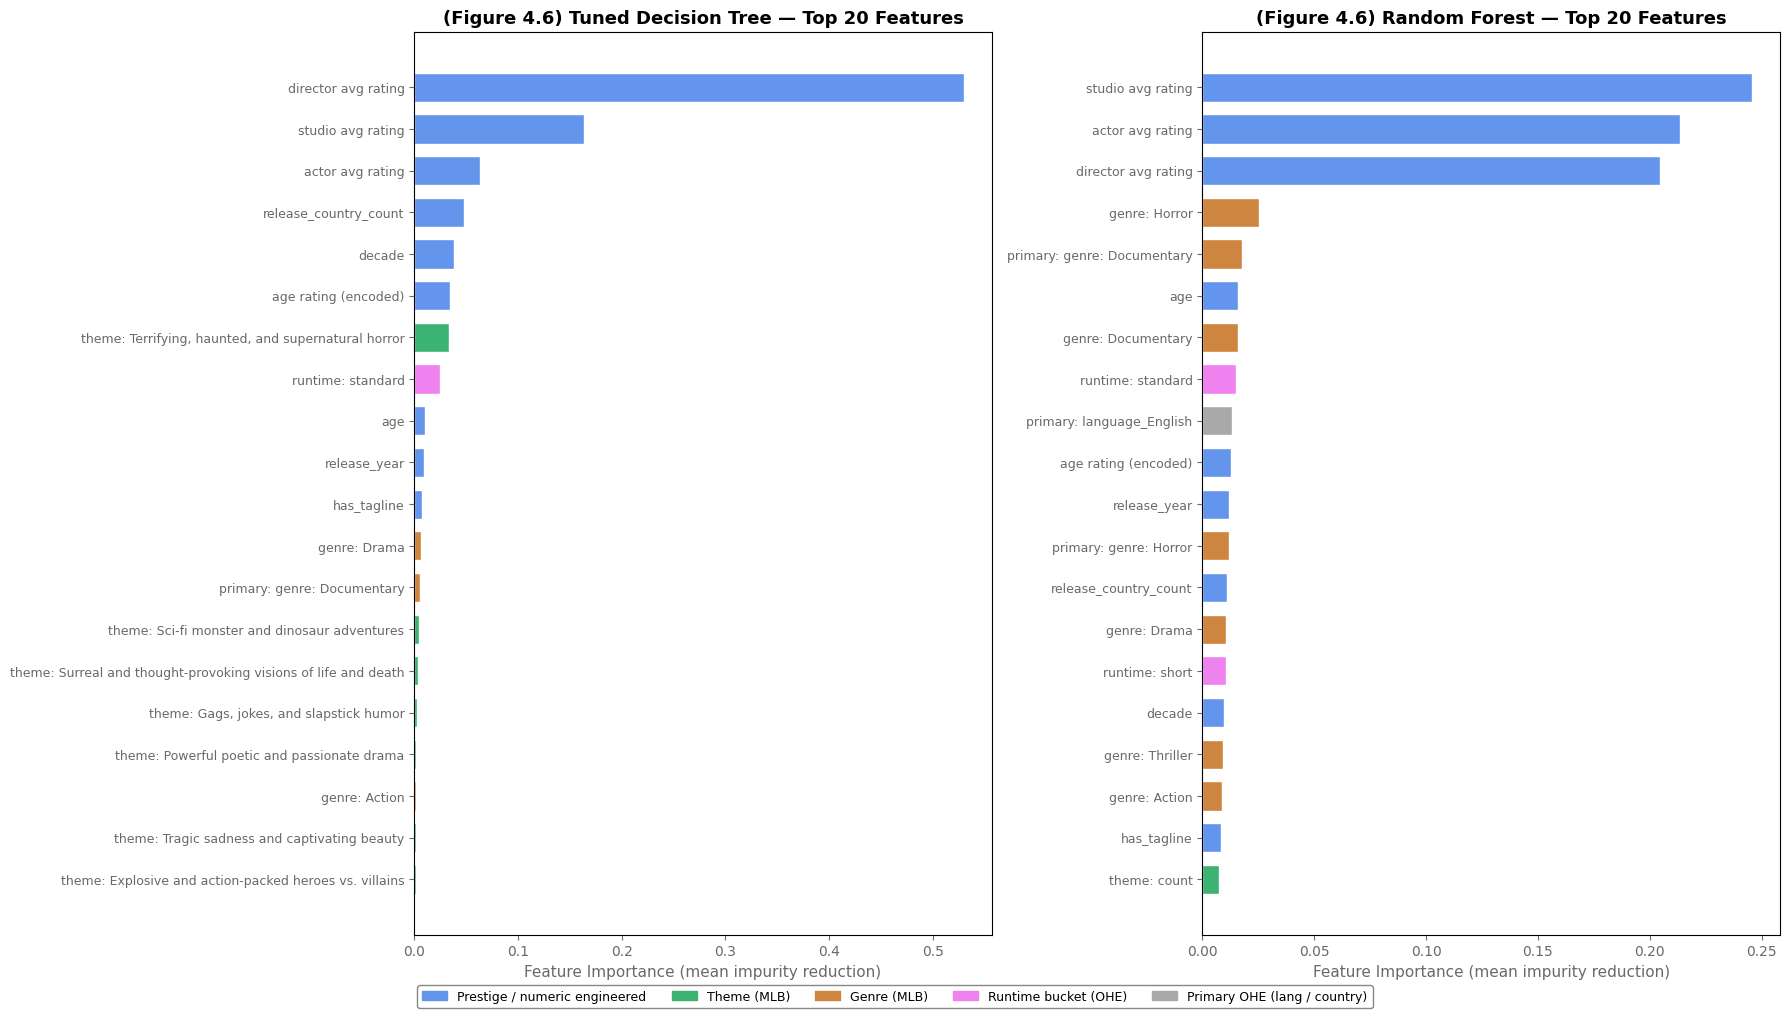


=== Decision Tree — Top 10 ===
director_avg_rating                                   0.530477
studio_avg_rating                                     0.163665
actor_avg_rating                                      0.063716
release_country_count                                 0.048405
decade                                                0.038227
age_rating_encoded                                    0.034089
theme_Terrifying, haunted, and supernatural horror    0.033688
runtime_bucket_standard                               0.024876
age                                                   0.010501
release_year                                          0.009185

=== Random Forest — Top 10 ===
studio_avg_rating            0.245888
actor_avg_rating             0.213706
director_avg_rating          0.204605
genre_Horror                 0.025163
primary_genre_Documentary    0.017858
age                          0.015823
genre_Documentary            0.015750
runtime_bucket_standard      0.015260
pr

In [70]:
# Decision Tree importances
dt_imp = pd.Series(tuned.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_imp = pd.Series(rf.feature_importances_,    index=X.columns).sort_values(ascending=False)

top_n = 20

def feature_color(name):
    if any(p in name for p in ['director_', 'studio_', 'actor_', 'age_rating']):
        return "cornflowerblue"
    if 'theme_'          in name: return "mediumseagreen"
    if 'genre_'          in name: return "peru"
    if 'primary_'        in name: return "darkgray"
    if 'runtime_bucket_' in name: return "violet"
    return "cornflowerblue"

fig, axes = plt.subplots(1, 2, figsize=(18, 10), facecolor="white")

for ax, imp, title in [
    (axes[0], dt_imp, f'(Figure 4.6) Tuned Decision Tree — Top {top_n} Features'),
    (axes[1], rf_imp, f'(Figure 4.6) Random Forest — Top {top_n} Features'),
]:
    ax.set_facecolor("white")
    top = imp.head(top_n)
    colors = [feature_color(n) for n in top.index]
    clean_labels = [
        n.replace('director_avg_rating', 'director avg rating')
         .replace('studio_avg_rating',   'studio avg rating')
         .replace('actor_avg_rating',    'actor avg rating')
         .replace('director_film_count', 'director film count')
         .replace('age_rating_encoded',  'age rating (encoded)')
         .replace('theme_','theme: ').replace('genre_','genre: ')
         .replace('primary_','primary: ').replace('runtime_bucket_','runtime: ')
        for n in top.index
    ]
    ax.barh(range(len(top)), top.values, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(clean_labels, fontsize=9, color="dimgray")
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance (mean impurity reduction)', fontsize=11, color="dimgray")
    ax.tick_params(colors="dimgray")
    ax.set_title(title, fontsize=13, fontweight='bold', color="black")

patches = [
    mpatches.Patch(color="cornflowerblue", label='Prestige / numeric engineered'),
    mpatches.Patch(color="mediumseagreen", label='Theme (MLB)'),
    mpatches.Patch(color="peru",           label='Genre (MLB)'),
    mpatches.Patch(color="violet",         label='Runtime bucket (OHE)'),
    mpatches.Patch(color="darkgray",       label='Primary OHE (lang / country)'),
]
fig.legend(handles=patches, fontsize=9, loc='lower center', ncol=5,
           facecolor="white", edgecolor="dimgray", labelcolor="black",
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

print("\n=== Decision Tree — Top 10 ===")
print(dt_imp.head(10).to_string())
print("\n=== Random Forest — Top 10 ===")
print(rf_imp.head(10).to_string())


## 5.5 Save-Final-RF-Model

In [71]:
with open(RF_MODEL_OUT, 'wb') as f:
    pickle.dump({
        'model':         rf,
        'feature_names': list(X.columns),
        'metrics': {
            'rmse': rf_rmse,
            'mae':  rf_mae,
            'r^2':  rf_r2,
        }
    }, f)

print(f"Model saved to path: {RF_MODEL_OUT}")
print(f"\nFinal metrics:")
print(f"\tRMSE\t: {rf_rmse:.4f}")
print(f"\tMAE\t: {rf_mae:.4f}")
print(f"\tR^2\t: {rf_r2:.4f}")

Model saved to path: c:\Users\kvais\OneDrive\Desktop\DSC578\FinalProject\letterboxd-rating-prediction\data\models\random_forest_model.pkl

Final metrics:
	RMSE	: 0.2287
	MAE	: 0.1586
	R^2	: 0.7028


---
# Section 6 - Linear Regression Models

## 6.1 Linear-Regression

In [72]:
df_linreg = pd.read_csv(PROCESSED_MODEL_READY_DATASET)
#Check Datatset size
df_linreg.shape

(90999, 482)

In [73]:
# Linear regression requires numeric features, so we check for any remaining categorical columns
df_linreg.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [74]:
# Confirming no categorical columns remain
df_linreg.select_dtypes(include=['object']).columns

Index([], dtype='str')

Although the dataset was previously preprocessed and encoded, we perform an additional check to ensure that no categorical(string) features remain, since Linear Regression requires all input features to be numeric.

In [75]:
X = df_linreg.drop("rating", axis=1) #Target variable is rating, so we drop it from the features
y = df_linreg["rating"]

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [77]:
# Training the regression model
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
#Generating predictors
y_pred = model.predict(X_test)

In [79]:
#Evaluating model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.023278728221811096
R² Score: 0.8669551338893917


In [80]:
#Examining coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
11,studio_avg_rating,0.575197
265,primary_country_Libya,0.365591
9,director_avg_rating,0.333245
12,actor_avg_rating,0.268576
198,primary_country_Botswana,0.205424
102,primary_language_Latin,0.147756
71,primary_language_Ganda,0.134079
346,primary_country_Yemen,0.109315
275,primary_country_Mauritius,0.100715
200,primary_country_Brunei Darussalam,0.092034


In [81]:
coefficients.sort_values(by="Coefficient").head(10)

,Feature,Coefficient
150,primary_language_Tajik,-0.397806
296,primary_country_Palau,-0.244102
326,primary_country_Svalbard and Jan Mayen,-0.172913
310,primary_country_Saint Kitts and Nevis,-0.125845
128,primary_language_Persian (Farsi),-0.116650
270,primary_country_Malawi,-0.112990
228,primary_country_Faroe Islands,-0.104598
170,primary_language_Yolngu matha,-0.099327
115,primary_language_Mayan,-0.087713
144,primary_language_Southern Sotho,-0.081313


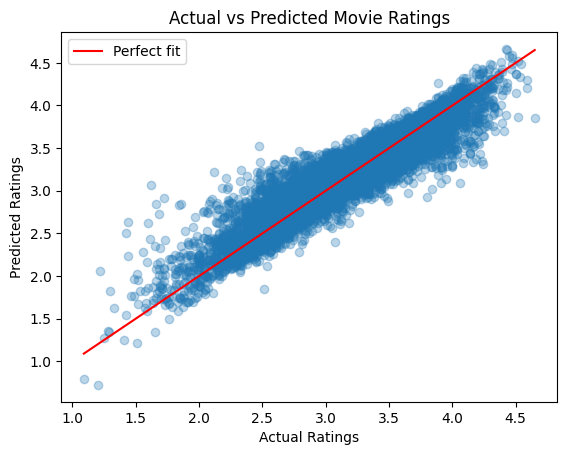

In [82]:
#Regresion diagnostics with plots between predicted and actual values
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=1.5, label='Perfect fit')
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")
plt.legend()
plt.show()

## 6.2 Ridge-Regression-(L2-Regularization)

### Motivation for Regularized Regression (Ridge and Lasso)

The baseline Linear Regression model was trained to predict movie ratings using the engineered features from the dataset. The model achieved an R² score of approximately 0.37 and a Mean Squared Error (MSE) of about 0.11. This indicates that the model is able to capture some of the variation in movie ratings, but a significant portion of the variance remains unexplained.

During exploratory data analysis, it was observed that most individual features have relatively weak correlations with the rating variable. This suggests that movie ratings are influenced by many small factors rather than a single dominant predictor. Additionally, after encoding categorical variables, the dataset contains a large number of features. High-dimensional feature spaces can lead to unstable coefficient estimates and increased variance in linear regression models.

The coefficient analysis also revealed that some predictors have relatively large coefficient values, which may indicate potential overfitting to the training data. In such situations, regularization techniques can help improve model stability and generalization performance.

To address these issues, regularized regression methods are introduced. Ridge regression (L2 regularization) reduces model variance by shrinking coefficient magnitudes, while Lasso regression (L1 regularization) can perform feature selection by forcing some coefficients to zero. These approaches help control model complexity and improve predictive robustness when working with datasets that contain many features.

In [83]:
# Initialize Ridge model
ridge_model = Ridge(alpha=1.0)

# Train model
ridge_model.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test)

In [84]:
#Evaluating the ridge model
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge MSE:", ridge_mse)
print("Ridge R2:", ridge_r2)

Ridge MSE: 0.023272810063654486
Ridge R2: 0.8669889579261718


## 6.3 Lasso-Regression-(L1-Regularization)

In [85]:
# Initialize Lasso model
lasso_model = Lasso(alpha=0.01)

# Train model
lasso_model.fit(X_train, y_train)

# Predict
y_pred_lasso = lasso_model.predict(X_test)

In [86]:
#Evaluating the lasso model
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso MSE:", lasso_mse)
print("Lasso R2:", lasso_r2)

Lasso MSE: 0.025404895319166624
Lasso R2: 0.8548034555802904


In [87]:
print("Linear Regression R2:", r2)
print("Ridge Regression R2:", ridge_r2)
print("Lasso Regression R2:", lasso_r2)

print("Linear Regression MSE:", mse)
print("Ridge Regression MSE:", ridge_mse)
print("Lasso Regression MSE:", lasso_mse)

Linear Regression R2: 0.8669551338893917
Ridge Regression R2: 0.8669889579261718
Lasso Regression R2: 0.8548034555802904
Linear Regression MSE: 0.023278728221811096
Ridge Regression MSE: 0.023272810063654486
Lasso Regression MSE: 0.025404895319166624


## 6.4 Analysis-Of-Linear-vs-Ridge

Ridge Regression produced almost identical performance to Linear Regression but with a slightly higher R² and slightly lower MSE, meaning:
- Ridge successfully stabilized coefficient magnitudes
- Regularization helped reduce variance slightly
- However, the improvement is very small
- This suggests the baseline model was already relatively stable, even with many features.

### Comparison of Linear, Ridge, and Lasso Regression

To evaluate whether regularization could improve the predictive performance of the baseline Linear Regression model, Ridge and Lasso regression models were also trained and evaluated.

The results show that Ridge Regression achieved a very similar R² scoren and MSE compared to the baseline Linear Regression model. This indicates that applying L2 regularization helped stabilize the model coefficients and marginally improved predictive performance.

In contrast, Lasso Regression produced a significantly lower R² score. Lasso applies L1 regularization, which forces some coefficients to zero and effectively performs feature selection. In this dataset, many features appear to contribute small amounts of predictive information, so removing these features resulted in reduced model performance.

Overall, Ridge Regression provided the best performance among the three models, although the improvement over the baseline Linear Regression model was relatively small. This suggests that the dataset does not suffer heavily from overfitting but benefits slightly from coefficient regularization. Ridge is more robust because its L2 regularization prevents any single feature from dominating with an extreme coefficient, which matters when making predictions on new, unseen data outside the test set. Linear Regression has no such protection.

In [88]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE':  [mse**0.5,      ridge_mse**0.5,      lasso_mse**0.5],
    'MAE':   [mean_absolute_error(y_test, y_pred),
              mean_absolute_error(y_test, y_pred_ridge),
              mean_absolute_error(y_test, y_pred_lasso)],
    'R^2':    [r2, ridge_r2, lasso_r2]
}).round(4)

comparison = comparison.sort_values('R^2', ascending=False).reset_index(drop=True)
comparison.index += 1 
print("Regression Model Rankings (by R^2)")
comparison

Regression Model Rankings (by R^2)


,Model,RMSE,MAE,R^2
1,Linear Regression,0.1526,0.1056,0.8670
2,Ridge Regression,0.1526,0.1055,0.8670
3,Lasso Regression,0.1594,0.1053,0.8548


## 6.5 Logistic-Regression-Bonus-Test

Logistic Regression is a classification algorithm, so the continuous rating variable must be converted into categorical classes. Movies with ratings >= 3.5 are labeled as high-rated (1) and movies with ratings below 3.5 are labeled as low-rated (0)

In [89]:
df_linreg["high_rating"] = (df_linreg["rating"] >= 3.5).astype(int)

Define the feature matrix (X) and classification target (y). The original 'rating' column is removed from the predictors to avoid data leakage, since it was used to create the classification label.

In [90]:
X = df_linreg.drop(["rating", "high_rating"], axis=1)
y = df_linreg["high_rating"]

Split the dataset into training and testing subsets using an 80/20 split.
The training set will be used to train the logistic regression model, while the testing set will be used to evaluate model performance on unseen data.

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Checking the distribution of the classification labels to ensure that the dataset is reasonably balanced between high-rated and low-rated movies. Highly imbalanced classes can negatively impact classification model performance

In [92]:
y.value_counts()

high_rating
0    66649
1    24350
Name: count, dtype: int64

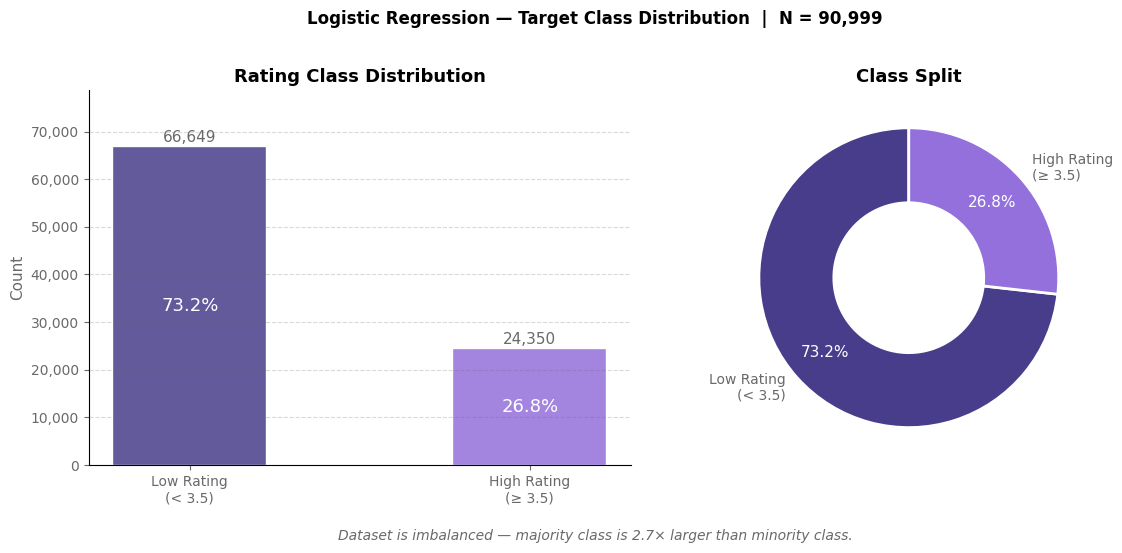

In [93]:
# Distribution of Movie Rating Classes
title_color       = "black"
axis_header_color = "dimgray"

class_counts = y.value_counts().sort_index()
total        = class_counts.sum()

# Descriptive labels
class_labels = {0: "Low Rating\n(< 3.5)", 1: "High Rating\n(≥ 3.5)"}
labels  = [class_labels[c] for c in class_counts.index]
colors  = ["darkslateblue", "mediumpurple"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="white")

# --- Bar chart ---
ax = axes[0]
ax.set_facecolor("white")

bars = ax.bar(
    labels, class_counts.values,
    color=colors, alpha=0.85,
    edgecolor="white", linewidth=0.3, width=0.45
)

for bar, val in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f"{val:,}",
        ha="center", va="bottom",
        fontsize=11, fontweight="500", color=axis_header_color
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{val/total*100:.1f}%",
        ha="center", va="center",
        fontsize=13, fontweight="500", color="white"
    )

ax.set_title("Rating Class Distribution", fontweight="bold",
             color=title_color, fontsize=13)
ax.set_ylabel("Count", color=axis_header_color, fontsize=11)
ax.set_ylim(0, class_counts.max() * 1.18)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25, color=axis_header_color)
ax.tick_params(colors=axis_header_color, labelsize=10)

# --- Donut chart ---
ax2 = axes[1]
ax2.set_facecolor("white")

wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
)

for text in texts:
    text.set_fontsize(10)
    text.set_color(axis_header_color)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("500")
    autotext.set_color("white")

ax2.set_title("Class Split", fontweight="bold",
              color=title_color, fontsize=13)

# Imbalance note
imbalance_ratio = class_counts.max() / class_counts.min()
fig.text(0.5, -0.04,
         f"Dataset is imbalanced — majority class is {imbalance_ratio:.1f}× larger than minority class.",
         ha="center", fontsize=10, color=axis_header_color, style="italic")

plt.suptitle(
    f"Logistic Regression — Target Class Distribution  |  N = {total:,}",
    fontweight="bold", color=title_color, fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

Standardizing the feature values so that all predictors have a similar scale.
Logistic Regression can perform better when features are normalized, especially when the dataset contains variables with different ranges

In [94]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Initialize and train the Logistic Regression model using the training dataset.
The model will learn the relationship between movie features and the probability that a movie belongs to the high-rating class.

In [95]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [96]:
#Generate predictions
y_pred = log_model.predict(X_test)

#Evaluating the model performance
accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {accuracy:.2f}")

# Class breakdown per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Accuracy: 0.90

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     13297
           1       0.84      0.78      0.81      4903

    accuracy                           0.90     18200
   macro avg       0.88      0.86      0.87     18200
weighted avg       0.90      0.90      0.90     18200

Confusion Matrix:
[[12590   707]
 [ 1081  3822]]


## 6.6 Save-Final-Ridge-Model

In [97]:
with open(RIDGE_MODEL_OUT, 'wb') as f:
    pickle.dump({
        'model':         ridge_model,
        'feature_names': list(X.columns),
        'metrics': {
            'mse': ridge_mse,
            'r^2': ridge_r2,
        }
    }, f)

print(f"Model saved to path: {RIDGE_MODEL_OUT}")
print(f"\nFinal metrics:")
print(f"\tMSE\t: {ridge_mse:.4f}")
print(f"\tR^2\t: {ridge_r2:.4f}")

Model saved to path: c:\Users\kvais\OneDrive\Desktop\DSC578\FinalProject\letterboxd-rating-prediction\data\models\ridge_model.pkl

Final metrics:
	MSE	: 0.0233
	R^2	: 0.8670


---
# Section 7 - K Nearest Neighbor (KNN)

## 7.1 Feature-Scale-Inspection

In [98]:
# Load Data
df_knn = pd.read_csv(PROCESSED_MODEL_READY_DATASET)
# Remove target temporarily
feature_df = df_knn.drop("rating", axis=1)

print("Minimum values (first 10 features):")
print(feature_df.min().head(10))

print("\nMaximum values (first 10 features):")
print(feature_df.max().head(10))

Minimum values (first 10 features):
release_year             1874.00
release_country_count       0.00
has_poster                  1.00
decade                   1870.00
age                         2.00
genre_count                 0.00
theme_count                 0.00
description_length          0.00
has_tagline                 0.00
director_avg_rating         1.05
dtype: float64

Maximum values (first 10 features):
release_year             2024.00
release_country_count     251.00
has_poster                  1.00
decade                   2020.00
age                       152.00
genre_count                 8.00
theme_count                10.00
description_length       1074.00
has_tagline                 1.00
director_avg_rating         4.69
dtype: float64


## 7.2 Train-Test-Split

In [99]:
X = df_knn.drop("rating", axis=1)
y = df_knn["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (72799, 481)
Test size: (18200, 481)


## 7.3 KNN-Normalization

MinMax scaling ensures:
- All features are in the same range
- No feature dominates distance calculations

In [100]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)

Scaled training shape: (72799, 481)


## 7.4 Baseline-KNN-(K=10)

In [101]:
# Initialize model
knn = KNeighborsRegressor(n_neighbors=10)

# Train model
knn.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Evaluation
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Training RMSE: 0.26401270588671927
Test RMSE: 0.2926909730659381


The small gap between training and test RMSE indicates that the KNN model with K=10 generalizes well and does not exhibit significant overfitting.

## 7.5 K-Sensitivity-Analysis

### Evaluate RMSE Across K Values

Test K from 5 to 100 (step = 5)

In [102]:
# Use smaller subset for K analysis
X_train_small = X_train_scaled[:15000]
y_train_small = y_train.iloc[:15000]

X_test_small = X_test_scaled[:5000]
y_test_small = y_test.iloc[:5000]

In [103]:
k_values = range(5, 101, 5)

train_rmse_list = []
test_rmse_list = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_small, y_train_small)

    y_train_pred = knn.predict(X_train_small)
    y_test_pred = knn.predict(X_test_small)

    train_rmse = np.sqrt(mean_squared_error(y_train_small, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_small, y_test_pred))

    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

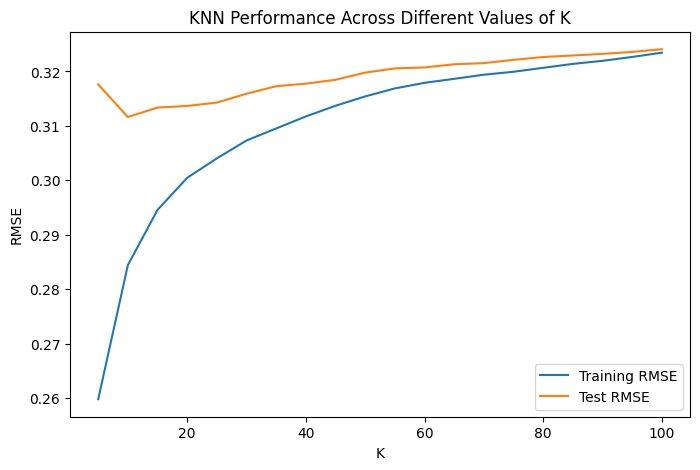

In [104]:
plt.figure(figsize=(8,5))
plt.plot(k_values, train_rmse_list, label="Training RMSE")
plt.plot(k_values, test_rmse_list, label="Test RMSE")

plt.xlabel("K")
plt.ylabel("RMSE")
plt.title("KNN Performance Across Different Values of K")
plt.legend()
plt.show()

The model exhibits overfitting at small values of K, where training error is low but test error is higher. As K increases, the model becomes more stable and test error decreases. The optimal performance occurs around K ≈ 20-25. Beyond this point, increasing K results in underfitting as the model becomes overly smooth.

## 7.6 Final-KNN-Model-(k=25)

In [105]:
# Final KNN model
final_knn = KNeighborsRegressor(n_neighbors=25)

# Train on full training data
final_knn.fit(X_train_scaled, y_train)

# Predictions
y_train_final = final_knn.predict(X_train_scaled)
y_test_final = final_knn.predict(X_test_scaled)

# Evaluation
train_rmse_final = np.sqrt(mean_squared_error(y_train, y_train_final))
test_rmse_final = np.sqrt(mean_squared_error(y_test, y_test_final))

print("Final Training RMSE:", train_rmse_final)
print("Final Test RMSE:", test_rmse_final)

Final Training RMSE: 0.28561890562712766
Final Test RMSE: 0.2970446969289746


The final KNN regression model was trained using K=25, selected based on the bias variance analysis performed earlier. The model achieved a training RMSE of ~0.286 and a test RMSE of ~0.297. The small difference between training and test error indicates that the model generalizes well to unseen data and does not suffer from significant overfitting. Given that movie ratings range roughly from 0.88 to 4.69 (a total range of about 3.8 points), an average prediction error of approximately 0.33 corresponds to less than 9% of the full rating scale. In other words, model captures meaningful structure in the data and provides reasonably accurate predictions.

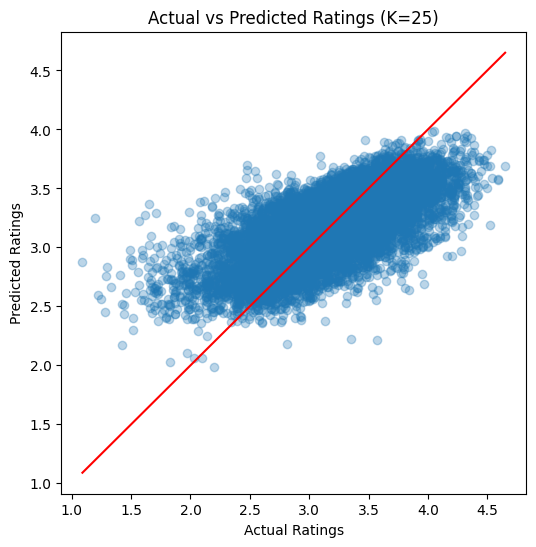

In [106]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_final, alpha=0.3)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (K=25)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1.5, label='Perfect fit')  # perfect prediction line
plt.show()

The scatter plot comparing actual versus predicted ratings shows a positive relationship. Most points cluster around the red diagonal line (which represents perfect predictions), suggesting that predictions are reasonably close to the true values. However, the spread of points increases toward the extremes of the rating scale. The model tends to slightly overpredict lower rated movies and underpredict very highly rated movies. This could indicate a  regression to the mean.

## 7.7 Save-Final-KNN-Model

In [107]:
with open(KNN_MODEL_OUT, 'wb') as f:
    pickle.dump({
        'model':         final_knn,
        'scaler':        scaler,
        'feature_names': list(X.columns),
        'metrics': {
            'rmse': test_rmse_final,
        }
    }, f)

print(f"Model saved to path: {KNN_MODEL_OUT}")
print(f"\nFinal metrics:")
print(f"\tRMSE\t: {test_rmse_final:.4f}")

Model saved to path: c:\Users\kvais\OneDrive\Desktop\DSC578\FinalProject\letterboxd-rating-prediction\data\models\knn_model.pkl

Final metrics:
	RMSE	: 0.2970


---
# Section 8 - Ensemble Model

| Layer | Models |
|---|---|
| **Level-0 (Base)** | Decision Tree, Random Forest, Ridge Regression, KNN |
| **Level-1 (Meta)** | XGBoost Regressor |

## 8.1 Load-Models

In [108]:
# Load the 4 model pkgs
dt_pkg = pickle.load(open(DECISION_TREE_MODEL_OUT, "rb"))
rf_pkg = pickle.load(open(RF_MODEL_OUT, "rb"))
ridge_pkg = pickle.load(open(RIDGE_MODEL_OUT, "rb"))
knn_pkg = pickle.load(open(KNN_MODEL_OUT, "rb"))

rf_model = rf_pkg["model"]
ridge_model = ridge_pkg["model"]
knn_model = knn_pkg["model"]
knn_scaler = knn_pkg["scaler"]

## 8.2 Load-Data-for-Ensemble

In [109]:
df_ensemble = pd.read_csv(PROCESSED_MODEL_READY_DATASET)

X = df_ensemble.drop(columns=["rating"])
y = df_ensemble["rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# scaled version for KNN
X_train_scaled = knn_scaler.transform(X_train)
X_test_scaled  = knn_scaler.transform(X_test)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (72799, 481)
Test: (18200, 481)


## 8.3 Generate-Base-Model-Predictions
Using the stacking strategy, we use out-of-fold predictions on the training set to train the meta-model. This prevents data leakage; each prediction is made on data the base model never trained on.

In [110]:
# out-of-fold predictions on training set (for meta-model training)
train_pred_rf = cross_val_predict(rf_model, X_train, y_train, cv=5, n_jobs=-1)
train_pred_ridge = cross_val_predict(ridge_model, X_train, y_train, cv=5, n_jobs=-1)
train_pred_knn = cross_val_predict(knn_model, X_train_scaled, y_train, cv=5, n_jobs=-1)

# predictions on test set (for meta-model evaluation)
test_pred_rf = rf_model.predict(X_test)
test_pred_ridge = ridge_model.predict(X_test)
test_pred_knn = knn_model.predict(X_test_scaled)

# stack into meta-features
meta_train = np.column_stack([train_pred_rf, train_pred_ridge, train_pred_knn])
meta_test = np.column_stack([test_pred_rf, test_pred_ridge, test_pred_knn])

print("Meta-train shape:", meta_train.shape)
print("Meta-test shape:", meta_test.shape)

Meta-train shape: (72799, 3)
Meta-test shape: (18200, 3)


## 8.4 Train-XGBoost-Meta-Regressor

In [111]:
meta_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=0
)

meta_model.fit(meta_train, y_train)
y_pred_ensemble = meta_model.predict(meta_test)

## 8.5 XGBoost-Model-Evaluation

In [112]:
ens_rmse = mean_squared_error(y_test, y_pred_ensemble) ** 0.5
ens_mae = mean_absolute_error(y_test, y_pred_ensemble)
ens_r2 = r2_score(y_test, y_pred_ensemble)

print(f"RMSE: {ens_rmse:.4f}")
print(f"MAE: {ens_mae:.4f}")
print(f"R^2: {ens_r2:.4f}")

RMSE: 0.1516
MAE: 0.1052
R^2: 0.8687


In [113]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Ridge Regression",
        "KNN (k=25)",
        "Ensemble (XGBoost Stack)"
    ],
    "RMSE": [
        mean_squared_error(y_test, test_pred_rf) ** 0.5,
        mean_squared_error(y_test, test_pred_ridge) ** 0.5,
        mean_squared_error(y_test, test_pred_knn) ** 0.5,
        ens_rmse
    ],
    "MAE": [
        mean_absolute_error(y_test, test_pred_rf),
        mean_absolute_error(y_test, test_pred_ridge),
        mean_absolute_error(y_test, test_pred_knn),
        ens_mae
    ],
    "R^2": [
        r2_score(y_test, test_pred_rf),
        r2_score(y_test, test_pred_ridge),
        r2_score(y_test, test_pred_knn),
        ens_r2
    ]
}).round(4)

comparison

,Model,RMSE,MAE,R^2
0,Random Forest,0.2256,0.1568,0.7092
1,Ridge Regression,0.1526,0.1055,0.8670
2,KNN (k=25),0.2970,0.2155,0.4957
3,Ensemble (XGBoost Stack),0.1516,0.1052,0.8687


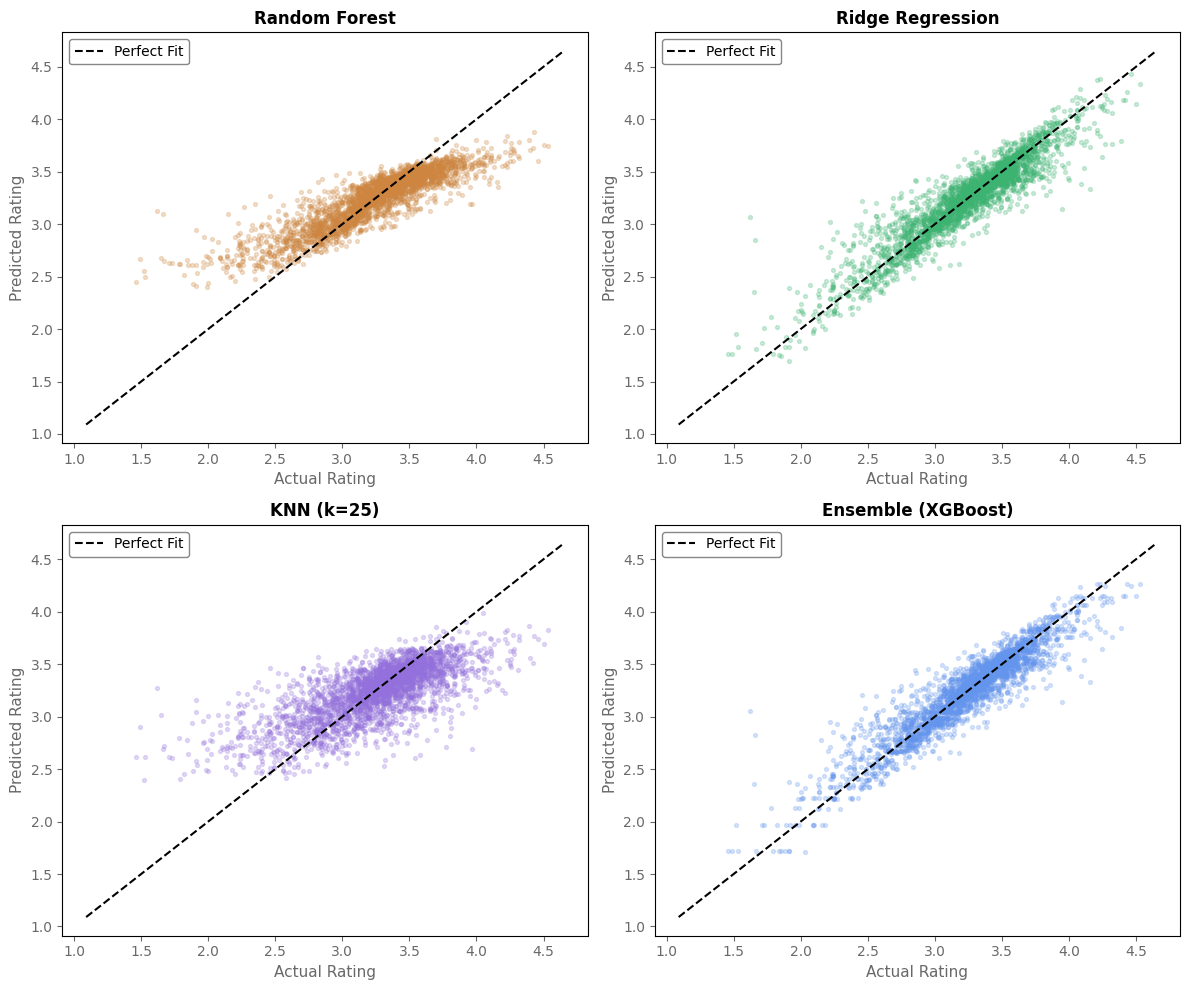

In [114]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor="white")
axes = axes.flatten()
for ax in axes:
    ax.set_facecolor("white")

np.random.seed(42)
sample = np.random.choice(len(y_test), 3000, replace=False)

plots = [
    ("Random Forest", test_pred_rf, "peru"),
    ("Ridge Regression", test_pred_ridge, "mediumseagreen"),
    ("KNN (k=25)", test_pred_knn, "mediumpurple"),
    ("Ensemble (XGBoost)", y_pred_ensemble, "cornflowerblue"),
]

lims = [float(y_test.min()), float(y_test.max())]

for ax, (title, preds, color) in zip(axes, plots):
    ax.scatter(
        np.array(y_test)[sample], preds[sample],
        alpha=0.25, s=8, color=color, rasterized=True
    )
    ax.plot(lims, lims, '--', color="black", linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual Rating', fontsize=11, color="dimgray")
    ax.set_ylabel('Predicted Rating', fontsize=11, color="dimgray")
    ax.set_title(title, fontsize=12, fontweight='bold', color="black")
    ax.tick_params(colors="dimgray")
    ax.legend(facecolor="white", edgecolor="dimgray", labelcolor="black")
plt.tight_layout()
plt.show()